# MSDS 6004 — Inteligencia Artificial · Taller 3
## P1 · Aprendizaje No Supervisado — Smart Building Dataset (SBDS)
### Análisis Univariable · Literales A, B y C

**Variables analizadas (una de cada tipo, según requerimiento):**

| Variable | Tipo | Descripción |
|---|---|---|
| `V005_vent01_CO2` | CO2 (ppm) | Ventilación Norte-Este — Concentración de CO2 |
| `V006_vent01_temp_out`| Temperatura (°C) | Ventilación Norte-Este — Temperatura de salida |

> Se eligen ambas del **mismo sector (Norte-Este)** para permitir cruces de información en la sección de plus.

**Patrón diario**: perfil de 24 puntos (00:00 – 23:00) por día completo.

---
### Hoja de ruta
1. **Carga y calidad de datos** — limpieza, matriz de perfiles diarios  
2. **Literal A** — Visualización + estadística descriptiva  
3. **Literal B** — Clústeres (3 técnicas: K-Means, Jerárquico Ward, GMM) + validación ANOVA + PCA  
4. **Literal C** — Anomalías (3 técnicas: Distancia, Isolation Forest, LOF) + explicación horaria  
5. **Plus — Análisis cruzado** entre CO2 y Temperatura  
6. **Conclusiones**

## 0 · Configuración

In [4]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import cdist

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (silhouette_score, silhouette_samples,
                              adjusted_rand_score, davies_bouldin_score,
                              calinski_harabasz_score)

PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4', '#E91E63', '#795548']
SAVE_PATH = 'images'
os.makedirs(SAVE_PATH, exist_ok=True)

RND = 42
np.random.seed(RND)
print('✓ Librerías cargadas correctamente.')

✓ Librerías cargadas correctamente.


## 1 · Carga y Calidad de Datos

Construimos una **matriz de perfiles diarios** `(días × 24 horas)` para cada variable. Se descartan los días con horas faltantes y los valores claramente fuera de rango físico (e.g. 0 °C en una sala interior).

In [5]:
DATA_PATH = os.path.join('..', 'data', 'data.csv')

df = pd.read_csv(DATA_PATH, sep=';')
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d.%m.%Y %H:%M')
df = df.sort_values('timestamp').reset_index(drop=True)
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour

# Filtrar valores físicamente imposibles para temperatura interior
df.loc[df['V006_vent01_temp_out'] < 5,  'V006_vent01_temp_out'] = np.nan
df.loc[df['V023_vent02_temp_out'] < 5,  'V023_vent02_temp_out'] = np.nan

print(f'Registros totales : {len(df):,}')
print(f'Rango temporal    : {df["timestamp"].min().date()} → {df["timestamp"].max().date()}')
print(f'Días únicos       : {df["date"].nunique():,}')
df.head(3)

Registros totales : 25,942
Rango temporal    : 2012-06-23 → 2015-06-08
Días únicos       : 1,081


,timestamp,V005_vent01_CO2,V022_vent02_CO2,V006_vent01_temp_out,V023_vent02_temp_out,date,hour
0,2012-06-23 01:00:00,494.172532,405.514287,22.700000,23.449972,2012-06-23,1
1,2012-06-23 02:00:00,491.992574,404.705170,22.700000,23.400000,2012-06-23,2
2,2012-06-23 03:00:00,490.003467,401.981443,22.628444,23.400000,2012-06-23,3


In [6]:
def build_daily_profile(df_raw: pd.DataFrame, varname: str):
    """Devuelve (X_matrix, dates_array) con perfiles diarios completos."""
    p = df_raw.pivot_table(index='date', columns='hour', values=varname, aggfunc='mean')
    p = p.dropna(axis=0, how='any')      # solo días con 24 h
    p.columns = [f'H{h:02d}' for h in p.columns]
    return p.values, pd.to_datetime(p.index)

VAR_CO2,  LBL_CO2 = 'V005_vent01_CO2',     'CO2 Ventilación NE (ppm)'
VAR_TMP,  LBL_TMP = 'V006_vent01_temp_out','Temperatura Ventilación NE (°C)'

X_co2, dates_co2 = build_daily_profile(df, VAR_CO2)
X_tmp, dates_tmp = build_daily_profile(df, VAR_TMP)

print(f'{VAR_CO2}: {X_co2.shape[0]} días completos × {X_co2.shape[1]} horas')
print(f'{VAR_TMP}: {X_tmp.shape[0]} días completos × {X_tmp.shape[1]} horas')

V005_vent01_CO2: 1079 días completos × 24 horas
V006_vent01_temp_out: 1076 días completos × 24 horas


---
# Literal A · Visualización + Estadística Descriptiva

**Objetivo del taller:** *"Plotear las variables — gráfico por cada variable que muestre sus valores superpuestos por cada día (...) Analizar una variable de cada tipo (1 CO2, 1 temperatura) presentar su estadística descriptiva."*

Se generan **cuatro vistas complementarias** para cada variable:
1. **Superposición** de los perfiles diarios — revela patrones y atípicos.
2. **Boxplot horario** — distribución condicionada por hora del día.
3. **Heatmap día × hora** — vista panorámica de toda la serie.
4. **Tabla descriptiva** — global y por hora.

In [7]:
sns.set_style('whitegrid')
HOURS = np.arange(24)

def plot_A_panel(X, label, color, fname):
    fig = plt.figure(figsize=(18, 11))
    gs  = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.25)

    # ── Panel 1: superposición ─────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    for row in X:
        ax1.plot(HOURS, row, color=color, alpha=0.06, linewidth=0.6)
    med  = np.median(X, axis=0)
    p25  = np.percentile(X, 25, axis=0)
    p75  = np.percentile(X, 75, axis=0)
    ax1.fill_between(HOURS, p25, p75, alpha=0.35, color='black', label='IQR (P25–P75)')
    ax1.plot(HOURS, med, color='black', linewidth=2.2, label='Mediana horaria')
    ax1.set_title(f'Perfiles Diarios Superpuestos · {label}', fontweight='bold')
    ax1.set_xlabel('Hora del día'); ax1.set_ylabel(label); ax1.set_xticks(HOURS)
    ax1.legend(loc='upper right')

    # ── Panel 2: boxplot horario ───────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    bp = ax2.boxplot(X, positions=HOURS, widths=0.6, patch_artist=True,
                     boxprops=dict(facecolor=color, alpha=0.55),
                     medianprops=dict(color='black', linewidth=1.6),
                     flierprops=dict(marker='.', markersize=2, color='gray', alpha=0.4))
    ax2.set_title(f'Distribución Horaria (Boxplot) · {label}', fontweight='bold')
    ax2.set_xlabel('Hora del día'); ax2.set_ylabel(label); ax2.set_xticks(HOURS)

    # ── Panel 3: heatmap día × hora ────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, :])
    im = ax3.imshow(X, aspect='auto', cmap='viridis',
                    extent=[0, 24, X.shape[0], 0])
    ax3.set_title(f'Heatmap Día × Hora · {label}  (cada fila = un día)', fontweight='bold')
    ax3.set_xlabel('Hora del día'); ax3.set_ylabel('Día (índice cronológico)')
    cbar = plt.colorbar(im, ax=ax3); cbar.set_label(label)

    plt.savefig(f'{SAVE_PATH}/{fname}', dpi=140, bbox_inches='tight')
    plt.show()

def descriptive_stats(X, label, dates):
    flat = X.flatten()
    g = pd.Series(flat).describe(percentiles=[.10, .25, .50, .75, .90])
    g['skew']  = stats.skew(flat)
    g['kurt']  = stats.kurtosis(flat)

    print(f'\n{"═"*60}')
    print(f'  Estadística Descriptiva GLOBAL — {label}')
    print(f'{"═"*60}')
    print(g.round(3).to_string())

    print(f'\n── Estadística por hora del día ─────────────────────────────')
    hourly = pd.DataFrame(X, columns=[f'H{h:02d}' for h in HOURS]).describe(
        percentiles=[.25, .50, .75]).T[['mean','std','min','25%','50%','75%','max']]
    print(hourly.round(2).to_string())

    print(f'\n→ Hora pico (mayor media): {hourly["mean"].idxmax()} ({hourly["mean"].max():.2f})')
    print(f'→ Hora valle (menor media): {hourly["mean"].idxmin()} ({hourly["mean"].min():.2f})')
    return hourly

### A.1 · CO2 — V005_vent01_CO2

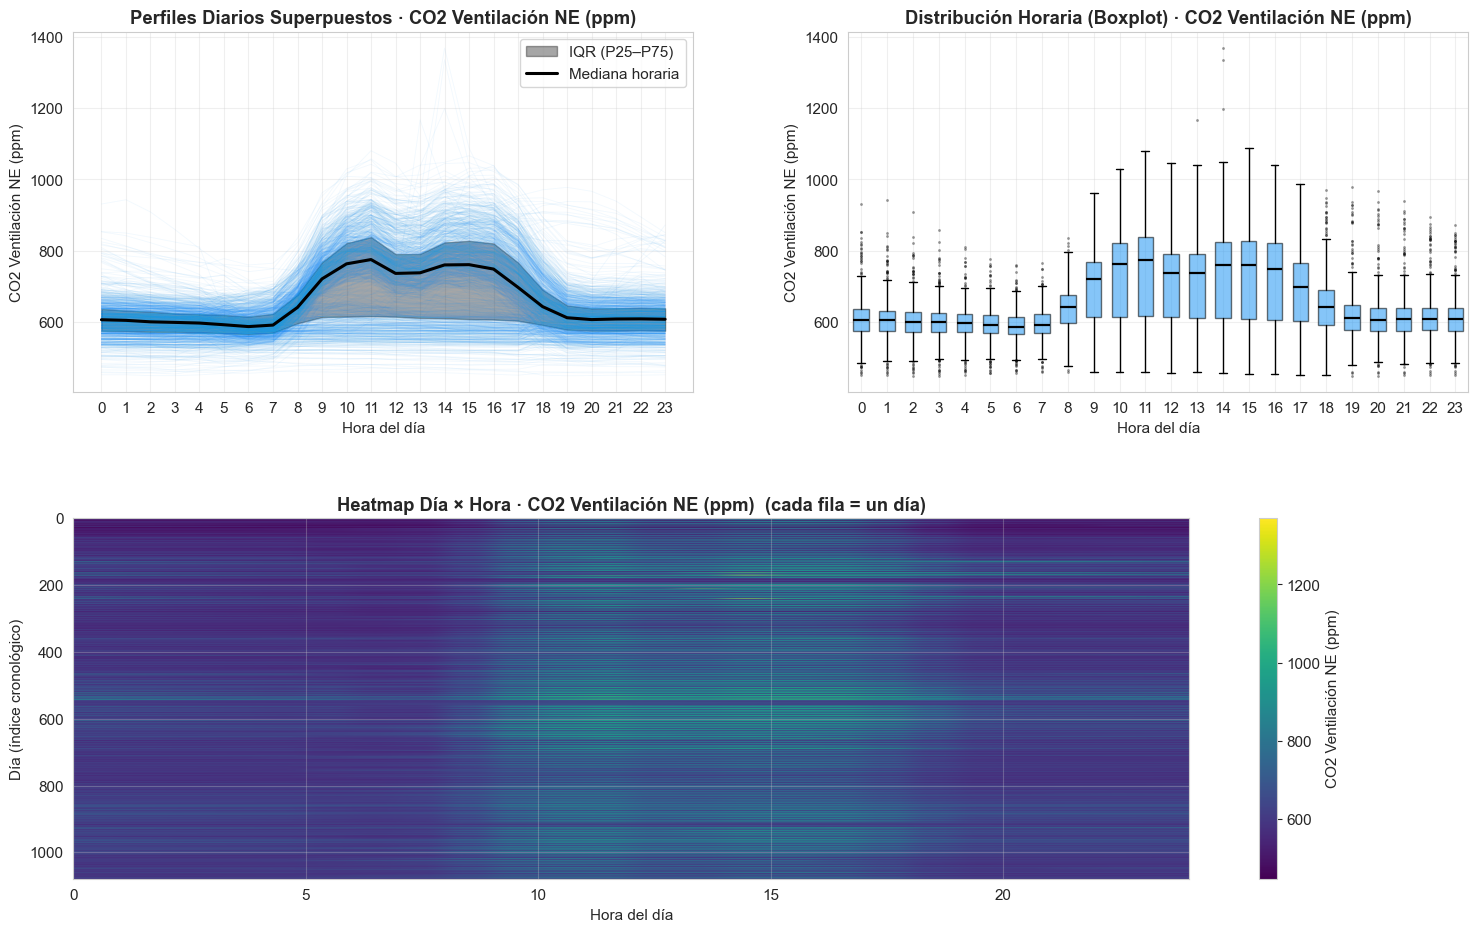

In [5]:
plot_A_panel(X_co2, LBL_CO2, '#2196F3', 'A1_CO2_perfiles.png')

In [6]:
hourly_co2 = descriptive_stats(X_co2, LBL_CO2, dates_co2)


════════════════════════════════════════════════════════════
  Estadística Descriptiva GLOBAL — CO2 Ventilación NE (ppm)
════════════════════════════════════════════════════════════
count    25896.000
mean       651.875
std        100.967
min        448.086
10%        551.540
25%        580.732
50%        620.282
75%        709.287
90%        807.224
max       1369.096
skew         1.046
kurt         0.663

── Estadística por hora del día ─────────────────────────────
       mean     std     min     25%     50%     75%      max
H00  607.37   52.64  450.87  574.44  605.57  635.93   930.82
H01  604.52   50.30  450.91  573.64  603.83  631.25   942.81
H02  601.34   47.82  448.45  571.51  599.70  628.02   908.46
H03  598.49   45.40  448.40  571.54  598.09  623.27   859.07
H04  596.42   43.04  450.68  569.93  596.25  621.14   810.61
H05  593.49   41.15  454.67  567.91  591.49  618.82   777.35
H06  589.82   40.21  455.11  565.27  586.32  613.99   759.58
H07  596.29   42.44  458.73  569.22  5

**Interpretación CO2:**
- Distribución asimétrica positiva (skew > 0): masa concentrada en niveles bajos con cola hacia valores altos → días de mayor ocupación.
- Hora pico ≈ media tarde, hora valle de madrugada → coherente con horario laboral.
- El IQR estrecho en horas centrales del día indica un comportamiento estable; las desviaciones grandes se concentrarán como anomalías en la sección C.

### A.2 · Temperatura — V006_vent01_temp_out

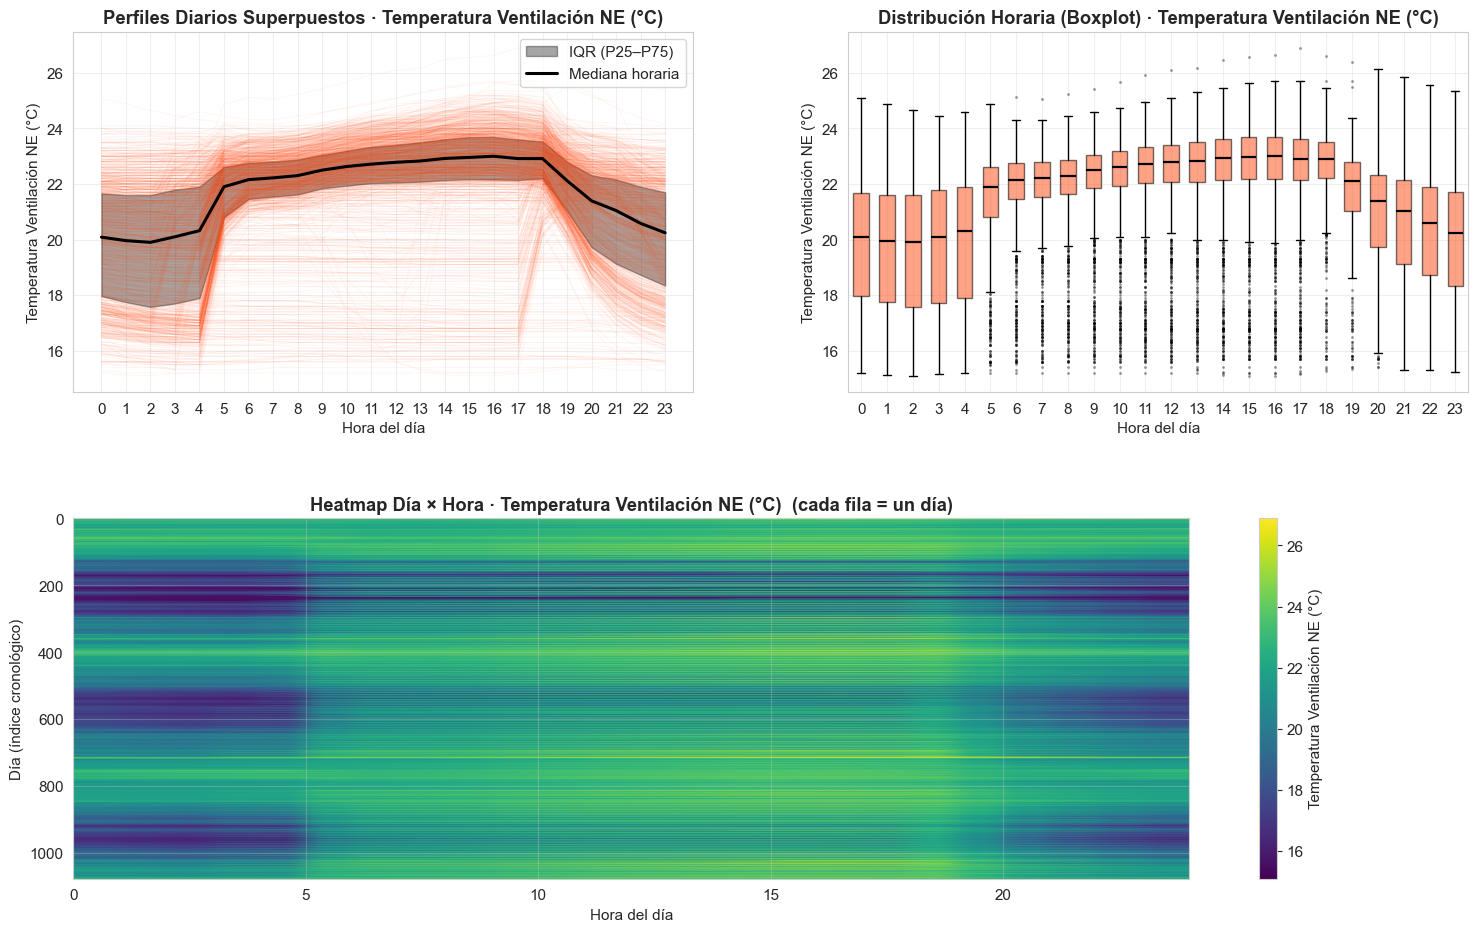

In [7]:
plot_A_panel(X_tmp, LBL_TMP, '#FF5722', 'A2_TMP_perfiles.png')

In [8]:
hourly_tmp = descriptive_stats(X_tmp, LBL_TMP, dates_tmp)


════════════════════════════════════════════════════════════
  Estadística Descriptiva GLOBAL — Temperatura Ventilación NE (°C)
════════════════════════════════════════════════════════════
count    25824.000
mean        21.347
std          2.211
min         15.100
10%         17.508
25%         20.100
50%         22.084
75%         22.935
90%         23.600
max         26.887
skew        -0.910
kurt        -0.089

── Estadística por hora del día ─────────────────────────────
      mean   std    min    25%    50%    75%    max
H00  19.87  2.09  15.20  17.97  20.09  21.66  25.09
H01  19.77  2.15  15.12  17.75  19.96  21.60  24.88
H02  19.71  2.20  15.11  17.58  19.90  21.60  24.64
H03  19.83  2.25  15.18  17.70  20.10  21.80  24.46
H04  19.98  2.28  15.20  17.90  20.32  21.90  24.59
H05  21.44  1.76  15.20  20.80  21.90  22.61  24.86
H06  21.69  1.76  15.20  21.46  22.16  22.76  25.12
H07  21.75  1.77  15.20  21.55  22.22  22.80  25.05
H08  21.81  1.80  15.20  21.62  22.30  22.88  25.22

**Interpretación Temperatura:**
- Distribución más simétrica que el CO2 (menor skew).
- La variabilidad horaria es **mucho más comprimida** (rango intercuartílico pequeño): el sistema de climatización mantiene la temperatura en una banda estable.
- El heatmap revela **patrones estacionales** (franjas más cálidas en verano y frías en invierno), algo que el CO2 no presenta tan marcadamente.

### A.3 Patrones por Día de Semana y Mes

Como valor agregado, exploramos si la **estacionalidad semanal** (laborable vs. fin de semana) y **mensual** ya se manifiesta en los datos crudos, antes de aplicar clustering. Esto orientará la interpretación posterior.

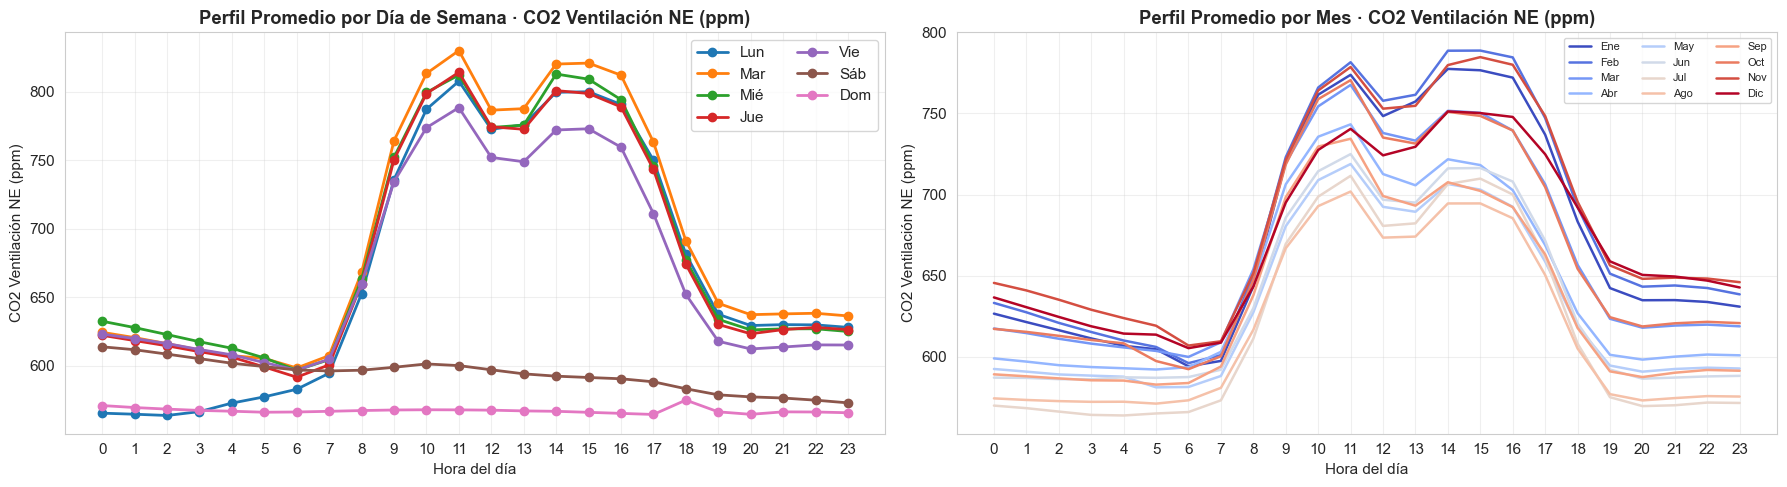

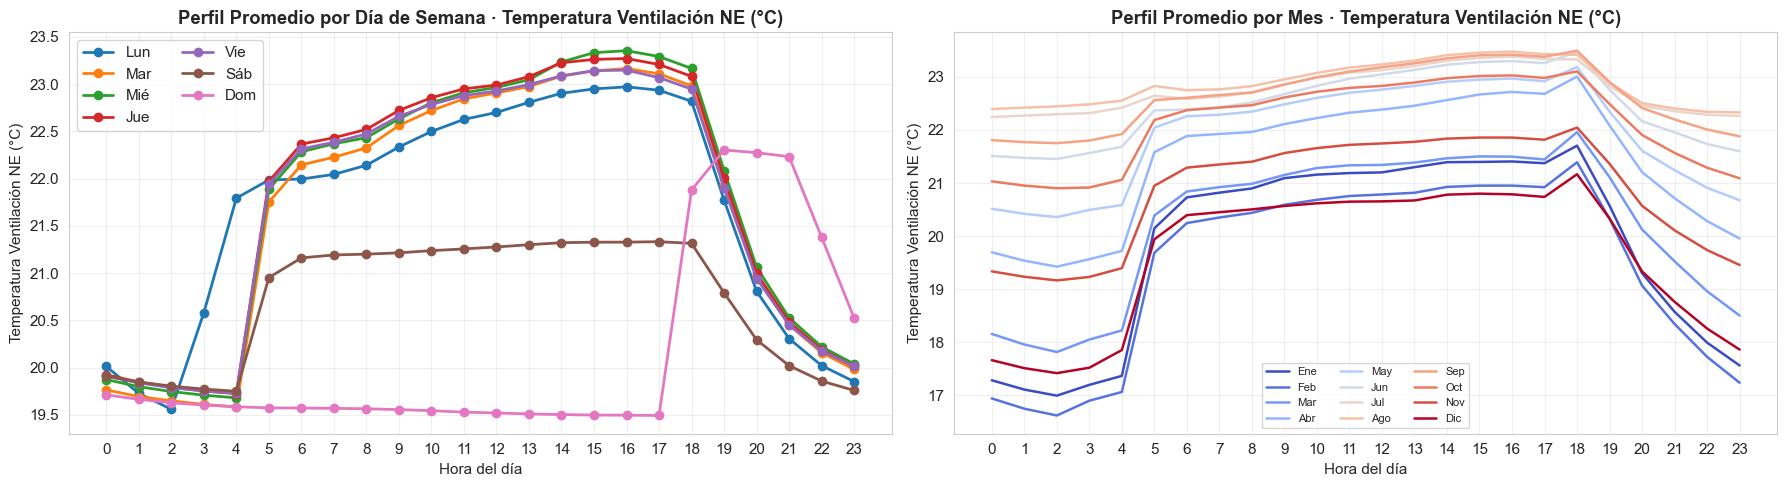

In [9]:
sns.set_style('whitegrid')
def plot_weekly_monthly(X, dates, label, color, fname):
    df_temp = pd.DataFrame(X, columns=[f'H{h:02d}' for h in HOURS])
    df_temp['weekday'] = dates.weekday
    df_temp['month']   = dates.month

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    dnames = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
    for wd in range(7):
        mean_prof = df_temp[df_temp['weekday']==wd].iloc[:, :24].mean(axis=0)
        axes[0].plot(HOURS, mean_prof, marker='o', linewidth=2, label=dnames[wd])
    axes[0].set_title(f'Perfil Promedio por Día de Semana · {label}', fontweight='bold')
    axes[0].set_xlabel('Hora del día'); axes[0].set_ylabel(label)
    axes[0].set_xticks(HOURS); axes[0].legend(ncol=2)

    mnames = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    cmap = plt.cm.coolwarm(np.linspace(0, 1, 12))
    for m in range(1, 13):
        sub = df_temp[df_temp['month']==m]
        if len(sub) > 0:
            axes[1].plot(HOURS, sub.iloc[:, :24].mean(axis=0),
                         color=cmap[m-1], linewidth=1.8, label=mnames[m-1])
    axes[1].set_title(f'Perfil Promedio por Mes · {label}', fontweight='bold')
    axes[1].set_xlabel('Hora del día'); axes[1].set_ylabel(label)
    axes[1].set_xticks(HOURS); axes[1].legend(ncol=3, fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{SAVE_PATH}/{fname}', dpi=140, bbox_inches='tight')
    plt.show()

plot_weekly_monthly(X_co2, dates_co2, LBL_CO2, '#2196F3', 'A3_CO2_weekly_monthly.png')
plot_weekly_monthly(X_tmp, dates_tmp, LBL_TMP, '#FF5722', 'A4_TMP_weekly_monthly.png')

**Hallazgo (extra):**
- **CO2** muestra una *separación clara entre días laborables (L–V) y fin de semana (S–D)*: la curva de fin de semana es notablemente más baja → fuerte señal de patrón de ocupación.
- **Temperatura** muestra estacionalidad fuerte por mes (más cálido en jun-ago, más frío en dic-feb) pero NO presenta la separación L–V tan marcada → la temperatura responde más al ambiente externo que a la ocupación.

Esto **anticipa** que los clústeres de CO2 codificarán "tipo de día" (laboral/no-laboral), mientras los de temperatura codificarán "estación del año".

---
# Literal B · Patrones / Clústeres — Análisis Univariable

**Objetivo del taller:** *"Encontrar los patrones diarios que existen en el data set, para cada variable individual. (...) Utilizar al menos dos técnicas para verificar su consistencia entre las dos técnicas."*

### Estrategia
Aplicamos **TRES técnicas independientes** (excede el mínimo de 2) sobre cada variable normalizada:

| # | Técnica | Familia | Por qué |
|---|---|---|---|
| 1 | **K-Means** | Particional, basado en centroides | Rápido, interpretable, base de referencia |
| 2 | **Aglomerativo Ward** | Jerárquico | No asume forma esférica, permite dendrograma |
| 3 | **Gaussian Mixture (GMM)** | Probabilístico | Maneja covarianzas elípticas; permite asignaciones blandas |

Selección de **k óptimo** mediante combinación de cuatro criterios: Elbow, Silhouette, Davies-Bouldin (↓ mejor) y Calinski-Harabasz (↑ mejor).

Validación final con:
- **Adjusted Rand Index (ARI)** — consistencia entre técnicas.
- **ANOVA por hora** — confirma que los clústeres son estadísticamente distintos.
- **Proyección PCA 2D** — visualización de la separabilidad.

In [10]:
sns.set_style('whitegrid')
def select_k(X_scaled, k_range=range(2, 9)):
    """Calcula 4 métricas para selección de k y devuelve resumen."""
    res = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RND, n_init=20).fit(X_scaled)
        labels = km.labels_
        res.append({
            'k': k,
            'inertia':   km.inertia_,
            'silhouette': silhouette_score(X_scaled, labels),
            'davies_bouldin':    davies_bouldin_score(X_scaled, labels),
            'calinski_harabasz': calinski_harabasz_score(X_scaled, labels)
        })
    return pd.DataFrame(res).set_index('k')

def plot_k_selection(metrics_df, label, fname):
    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    items = [('inertia','Inercia (Elbow)','steelblue','min'),
             ('silhouette','Silhouette Score (↑ mejor)','#FF5722','max'),
             ('davies_bouldin','Davies-Bouldin (↓ mejor)','#4CAF50','min'),
             ('calinski_harabasz','Calinski-Harabasz (↑ mejor)','#9C27B0','max')]
    for (col, title, c, optim), ax in zip(items, axes.flat):
        ax.plot(metrics_df.index, metrics_df[col], 'o-', color=c, lw=2, ms=8)
        ax.set_title(title, fontweight='bold'); ax.set_xlabel('k'); ax.set_xticks(metrics_df.index)
        best_k = metrics_df[col].idxmin() if optim == 'min' else metrics_df[col].idxmax()
        if col != 'inertia':
            ax.axvline(best_k, color='red', ls='--', lw=1.2,
                       label=f'óptimo k={best_k}')
            ax.legend()
    plt.suptitle(f'Selección de k · {label}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{SAVE_PATH}/{fname}', dpi=140, bbox_inches='tight')
    plt.show()

def run_three_clusterings(X_scaled, k):
    km  = KMeans(n_clusters=k, random_state=RND, n_init=20).fit(X_scaled)
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(X_scaled)
    gmm = GaussianMixture(n_components=k, random_state=RND, n_init=5).fit(X_scaled)
    return {
        'kmeans': km.labels_,
        'ward':   agg.labels_,
        'gmm':    gmm.predict(X_scaled),
        'km_obj': km, 'gmm_obj': gmm
    }

def align_labels_to_kmeans(labels_ref, labels_other, k):
    """Renombra etiquetas para maximizar coincidencia con referencia."""
    from itertools import permutations
    best_perm, best_score = None, -1
    for perm in permutations(range(k)):
        mapped = np.array([perm[l] for l in labels_other])
        score  = (mapped == labels_ref).mean()
        if score > best_score:
            best_score, best_perm = score, perm
    return np.array([best_perm[l] for l in labels_other])

## B.1 · CO2 · Selección de k

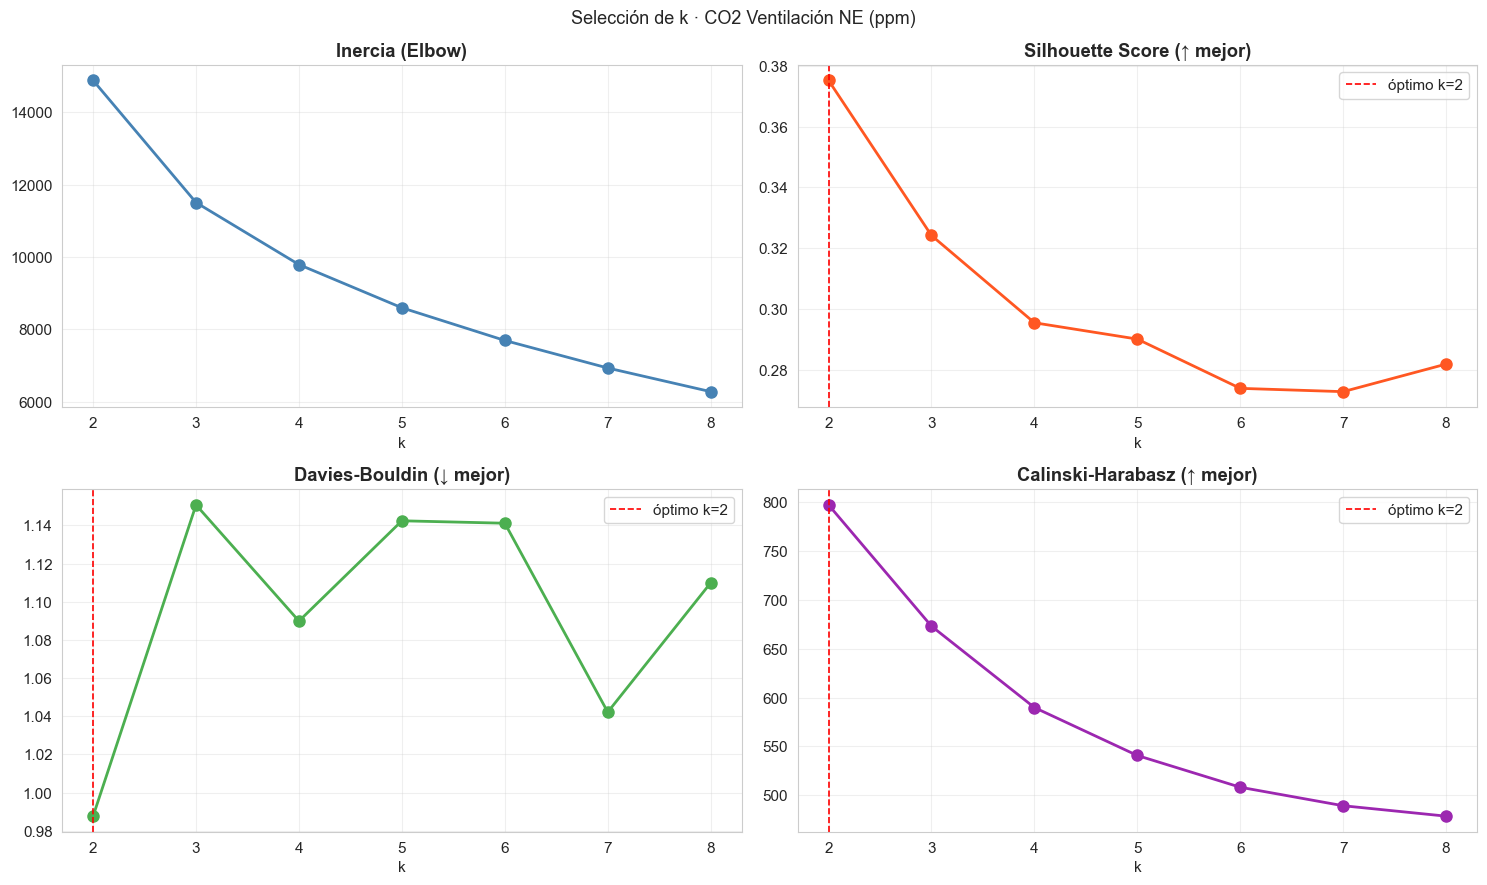

      inertia  silhouette  davies_bouldin  calinski_harabasz
k                                                           
2  14878.9066      0.3751          0.9877           797.4652
3  11502.7327      0.3243          1.1508           673.1946
4   9786.9073      0.2956          1.0899           589.8109
5   8592.9132      0.2903          1.1424           540.6640
6   7689.2721      0.2741          1.1412           508.1318
7   6927.8916      0.2730          1.0422           489.1775
8   6274.1351      0.2821          1.1099           478.4955

→ k óptimo para CO2 (por Silhouette): k = 2


In [11]:
scaler_co2 = StandardScaler()
Xs_co2 = scaler_co2.fit_transform(X_co2)

metrics_co2 = select_k(Xs_co2)
plot_k_selection(metrics_co2, LBL_CO2, 'B1_CO2_k_selection.png')
print(metrics_co2.round(4))

K_CO2 = int(metrics_co2['silhouette'].idxmax())
print(f'\n→ k óptimo para CO2 (por Silhouette): k = {K_CO2}')

## B.2 · CO2 · Ajuste de las 3 técnicas y comparación

═══════════════════════════════════════════════════════
  CO2 · Consistencia entre técnicas (Adjusted Rand Index)
═══════════════════════════════════════════════════════
         K-Means    Ward     GMM
K-Means   1.0000  0.6935  0.4560
Ward      0.6935  1.0000  0.6542
GMM       0.4560  0.6542  1.0000


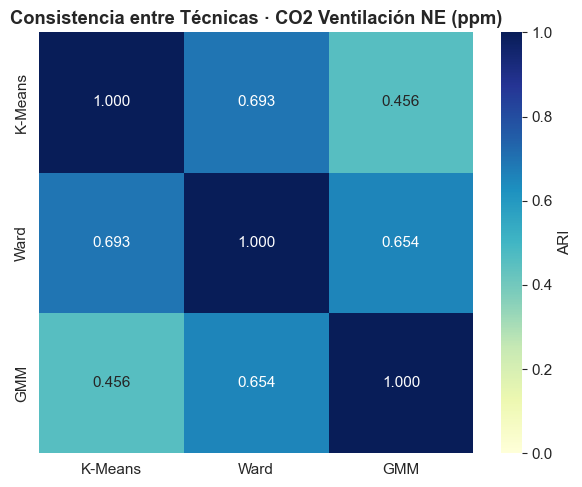

In [12]:
sns.set_style('whitegrid')
clust_co2 = run_three_clusterings(Xs_co2, K_CO2)

# Alinear etiquetas para comparación visual
lbl_km  = clust_co2['kmeans']
lbl_war = align_labels_to_kmeans(lbl_km, clust_co2['ward'], K_CO2)
lbl_gmm = align_labels_to_kmeans(lbl_km, clust_co2['gmm'],  K_CO2)

# Centroides de cada técnica (medias por clúster en escala ORIGINAL)
centroids_km  = np.array([X_co2[lbl_km == c].mean(0)  for c in range(K_CO2)])
centroids_war = np.array([X_co2[lbl_war == c].mean(0) for c in range(K_CO2)])
centroids_gmm = np.array([X_co2[lbl_gmm == c].mean(0) for c in range(K_CO2)])

# ── Consistencia: matriz ARI ─────────────────────────────────────────────────
ari_matrix = pd.DataFrame({
    'K-Means':    [1.0,
                   adjusted_rand_score(lbl_km, lbl_war),
                   adjusted_rand_score(lbl_km, lbl_gmm)],
    'Ward':       [adjusted_rand_score(lbl_km, lbl_war), 1.0,
                   adjusted_rand_score(lbl_war, lbl_gmm)],
    'GMM':        [adjusted_rand_score(lbl_km, lbl_gmm),
                   adjusted_rand_score(lbl_war, lbl_gmm), 1.0],
}, index=['K-Means','Ward','GMM'])

print('═'*55)
print(f'  CO2 · Consistencia entre técnicas (Adjusted Rand Index)')
print('═'*55)
print(ari_matrix.round(4).to_string())

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(ari_matrix, annot=True, cmap='YlGnBu', vmin=0, vmax=1,
            fmt='.3f', ax=ax, cbar_kws={'label':'ARI'})
ax.set_title(f'Consistencia entre Técnicas · {LBL_CO2}', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/B2_CO2_ari.png', dpi=140, bbox_inches='tight')
plt.show()

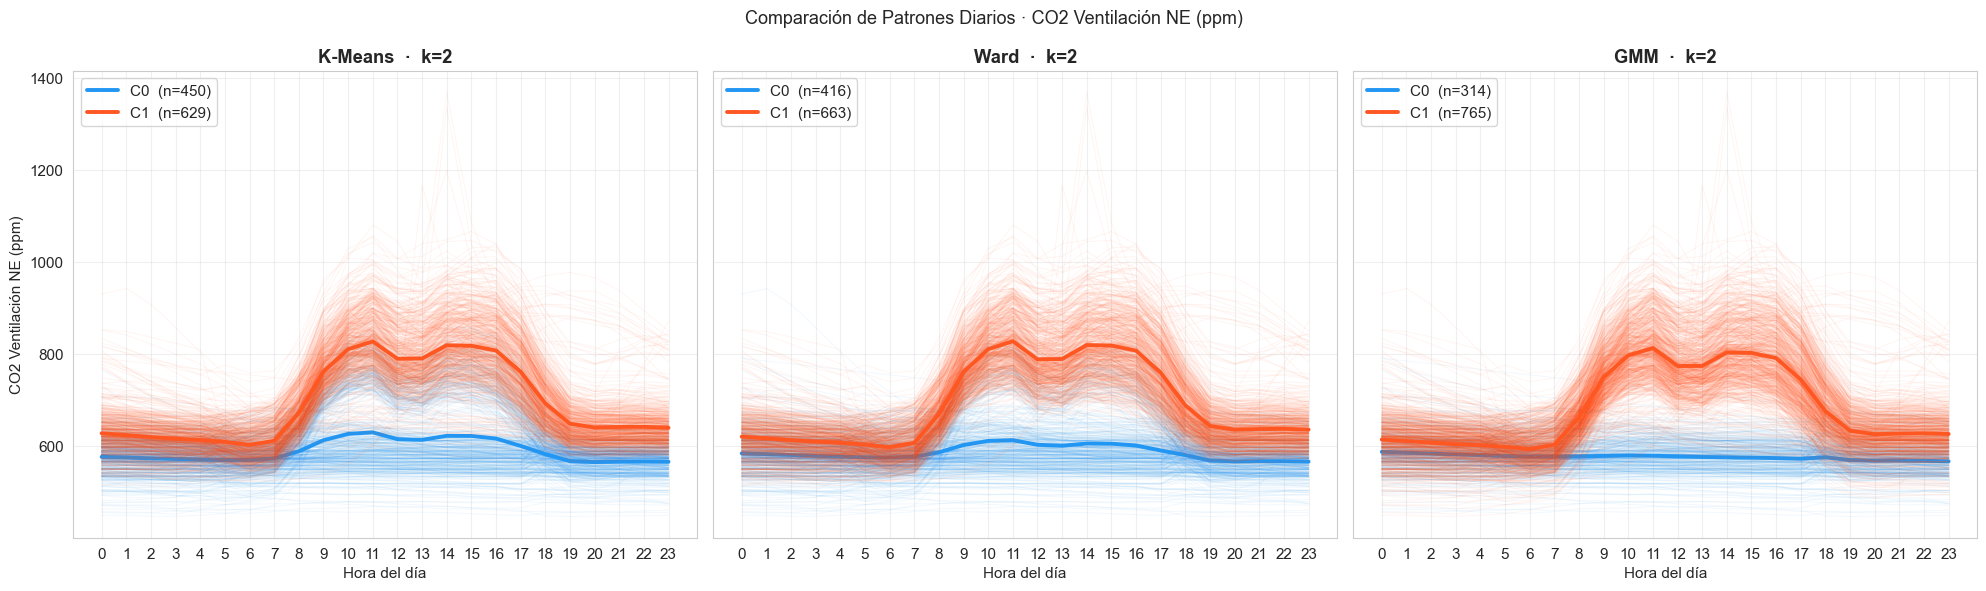

In [13]:
sns.set_style('whitegrid')
# ── Visualización de centroides de las 3 técnicas lado a lado ────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
techs = [('K-Means', lbl_km, centroids_km),
         ('Ward',    lbl_war, centroids_war),
         ('GMM',     lbl_gmm, centroids_gmm)]
for ax, (name, lbls, cents) in zip(axes, techs):
    for c in range(K_CO2):
        m = lbls == c
        for row in X_co2[m]:
            ax.plot(HOURS, row, color=PALETTE[c], alpha=0.06, lw=0.7)
        ax.plot(HOURS, cents[c], color=PALETTE[c], lw=2.8,
                label=f'C{c}  (n={m.sum()})')
    ax.set_title(f'{name}  ·  k={K_CO2}', fontweight='bold')
    ax.set_xlabel('Hora del día'); ax.set_xticks(HOURS); ax.legend(loc='upper left')
axes[0].set_ylabel(LBL_CO2)
plt.suptitle(f'Comparación de Patrones Diarios · {LBL_CO2}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/B3_CO2_centroides_3tec.png', dpi=140, bbox_inches='tight')
plt.show()

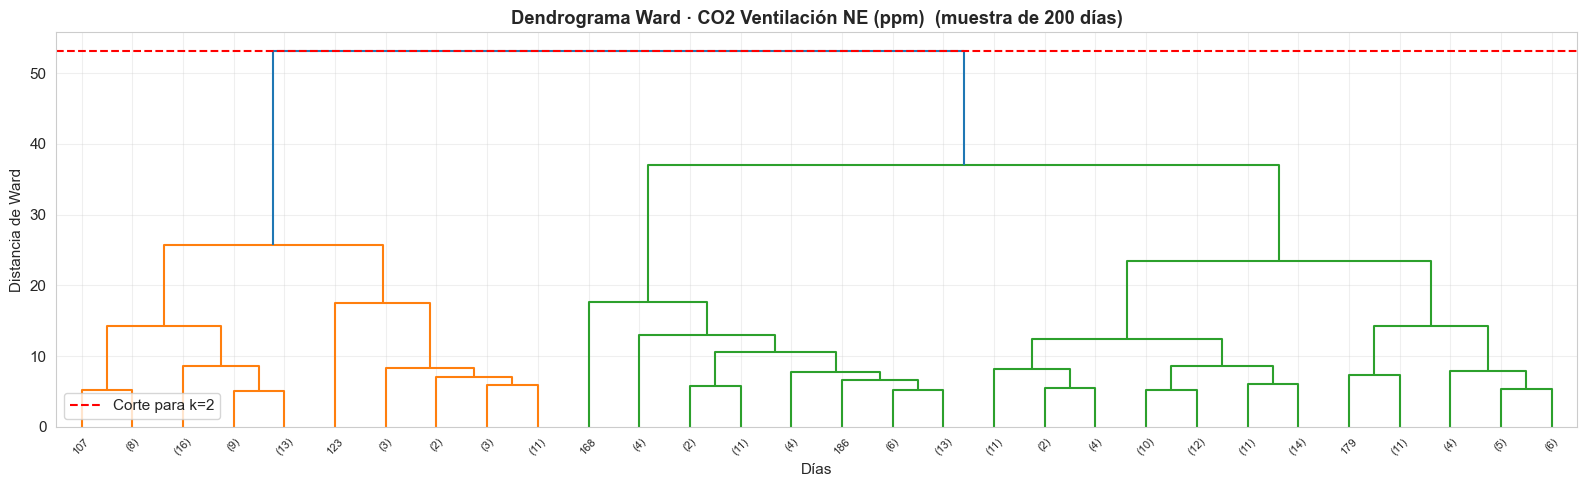

In [14]:
sns.set_style('whitegrid')
# Dendrograma (muestra para legibilidad)
idx_sample = np.random.RandomState(RND).choice(len(Xs_co2),
                                                size=min(200, len(Xs_co2)), replace=False)
Z_co2 = linkage(Xs_co2[idx_sample], method='ward')
fig, ax = plt.subplots(figsize=(16, 5))
dendrogram(Z_co2, ax=ax, truncate_mode='lastp', p=30, leaf_rotation=45,
           leaf_font_size=8, color_threshold=Z_co2[-K_CO2+1, 2])
ax.axhline(Z_co2[-K_CO2+1, 2], color='red', ls='--', lw=1.5,
           label=f'Corte para k={K_CO2}')
ax.set_title(f'Dendrograma Ward · {LBL_CO2}  (muestra de 200 días)', fontweight='bold')
ax.set_xlabel('Días'); ax.set_ylabel('Distancia de Ward'); ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/B4_CO2_dendrograma.png', dpi=140, bbox_inches='tight')
plt.show()

### B.3 · CO2 · Proyección PCA 2D y caracterización temporal de clústeres

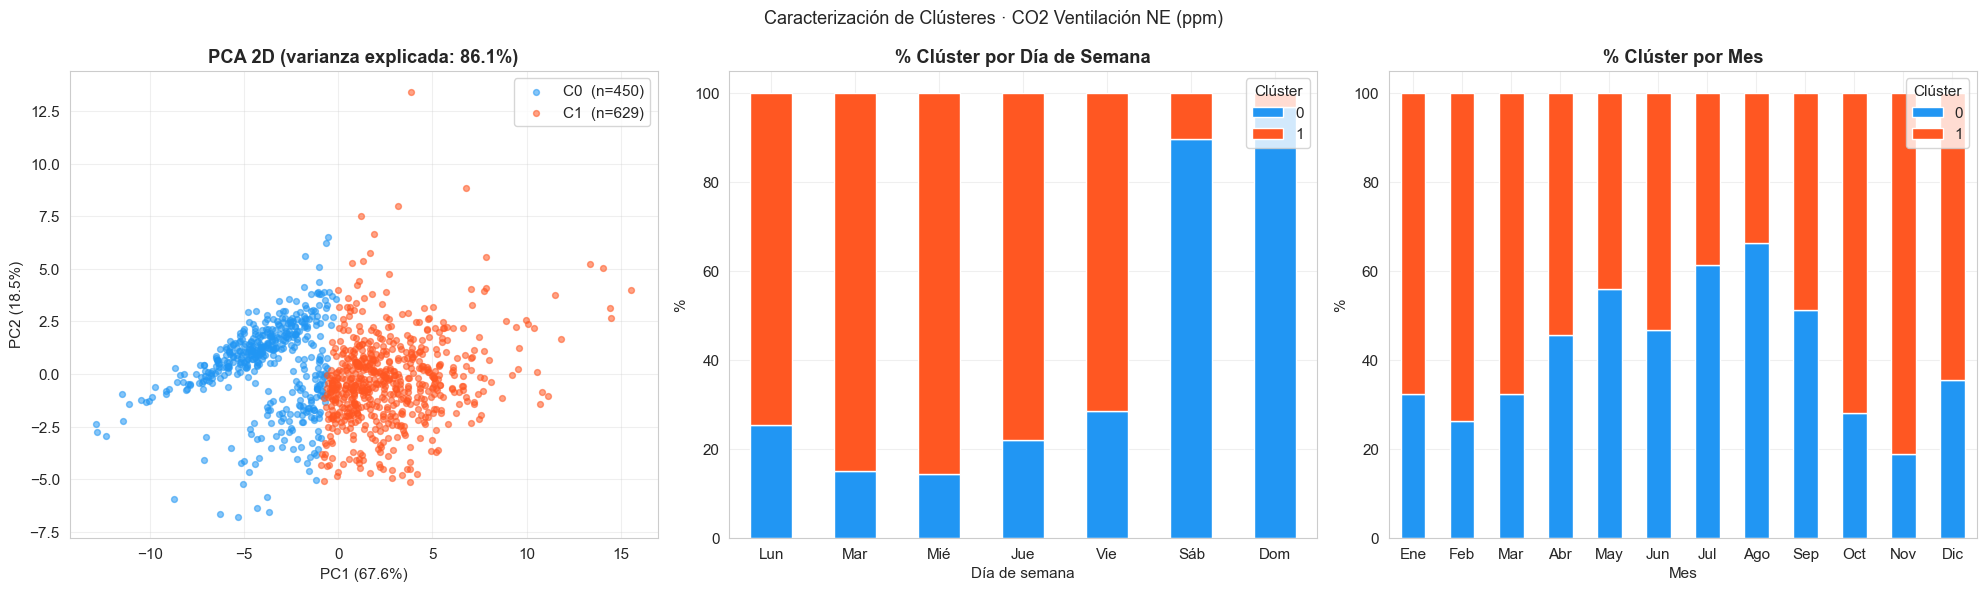

In [15]:
sns.set_style('whitegrid')
pca_co2 = PCA(n_components=2, random_state=RND)
Xp_co2 = pca_co2.fit_transform(Xs_co2)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── (1) Scatter PCA con clúster K-Means ───────────────────────────────────────
for c in range(K_CO2):
    m = lbl_km == c
    axes[0].scatter(Xp_co2[m, 0], Xp_co2[m, 1], color=PALETTE[c], alpha=0.55,
                    s=18, label=f'C{c}  (n={m.sum()})')
axes[0].set_title(f'PCA 2D (varianza explicada: {pca_co2.explained_variance_ratio_.sum()*100:.1f}%)')
axes[0].set_xlabel(f'PC1 ({pca_co2.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_co2.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# ── (2) Distribución por día de semana ────────────────────────────────────────
df_lbl_co2 = pd.DataFrame({'cluster': lbl_km, 'weekday': dates_co2.weekday,
                            'month': dates_co2.month})
ct_wd = pd.crosstab(df_lbl_co2['weekday'], df_lbl_co2['cluster'], normalize='index') * 100
ct_wd.plot(kind='bar', stacked=True, ax=axes[1],
           color=[PALETTE[c] for c in ct_wd.columns], edgecolor='white')
axes[1].set_title('% Clúster por Día de Semana', fontweight='bold')
axes[1].set_xlabel('Día de semana')
axes[1].set_xticklabels(['Lun','Mar','Mié','Jue','Vie','Sáb','Dom'], rotation=0)
axes[1].set_ylabel('%')
axes[1].legend(title='Clúster', loc='upper right')

# ── (3) Distribución por mes ─────────────────────────────────────────────────
ct_m = pd.crosstab(df_lbl_co2['month'], df_lbl_co2['cluster'], normalize='index') * 100
ct_m.plot(kind='bar', stacked=True, ax=axes[2],
          color=[PALETTE[c] for c in ct_m.columns], edgecolor='white')
axes[2].set_title('% Clúster por Mes', fontweight='bold')
axes[2].set_xlabel('Mes')
axes[2].set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'], rotation=0)
axes[2].set_ylabel('%')
axes[2].legend(title='Clúster')

plt.suptitle(f'Caracterización de Clústeres · {LBL_CO2}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/B5_CO2_pca_y_calendar.png', dpi=140, bbox_inches='tight')
plt.show()

### B.4 Validación estadística (ANOVA por hora)

¿Son los clústeres *estadísticamente distintos*? Aplicamos ANOVA de una vía hora por hora: si en la mayoría de horas el p-valor es < 0.05, los clústeres no son producto del azar.

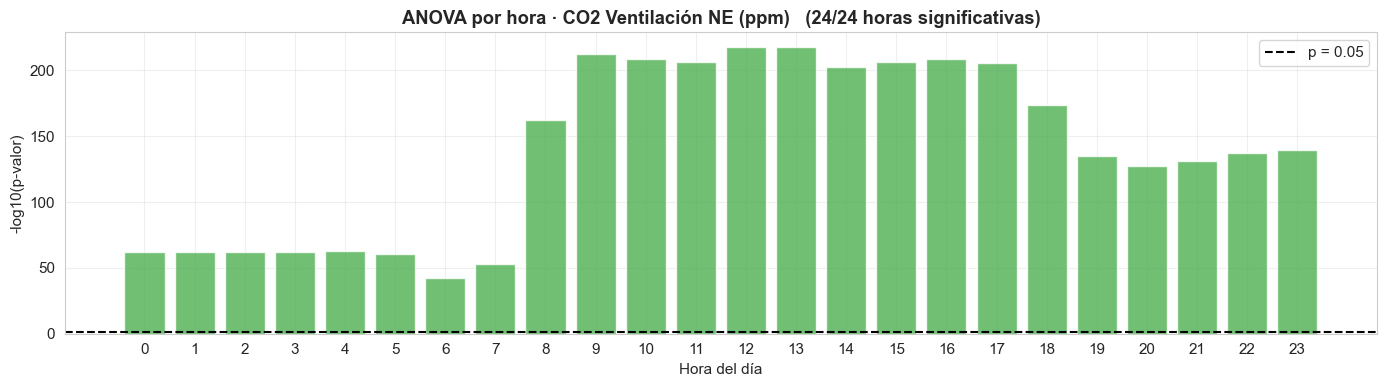

✓ 24/24 horas con diferencias estadísticamente significativas entre clústeres (p<0.05).


In [16]:
sns.set_style('whitegrid')
def anova_by_hour(X, labels, k):
    pvals = []
    for h in range(24):
        groups = [X[labels == c, h] for c in range(k)]
        _, p = stats.f_oneway(*groups)
        pvals.append(p)
    return np.array(pvals)

pvals_co2 = anova_by_hour(X_co2, lbl_km, K_CO2)
n_sig = (pvals_co2 < 0.05).sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(HOURS, -np.log10(pvals_co2 + 1e-300),
       color=['#4CAF50' if p<0.05 else '#FF5722' for p in pvals_co2], alpha=0.8)
ax.axhline(-np.log10(0.05), color='black', ls='--', lw=1.5, label='p = 0.05')
ax.set_title(f'ANOVA por hora · {LBL_CO2}   ({n_sig}/24 horas significativas)', fontweight='bold')
ax.set_xlabel('Hora del día'); ax.set_ylabel('-log10(p-valor)')
ax.set_xticks(HOURS); ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/B6_CO2_anova.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'✓ {n_sig}/24 horas con diferencias estadísticamente significativas entre clústeres (p<0.05).')

---
## B.5 · Temperatura · Repetimos el pipeline

Aplicamos exactamente la misma metodología a la variable de temperatura.

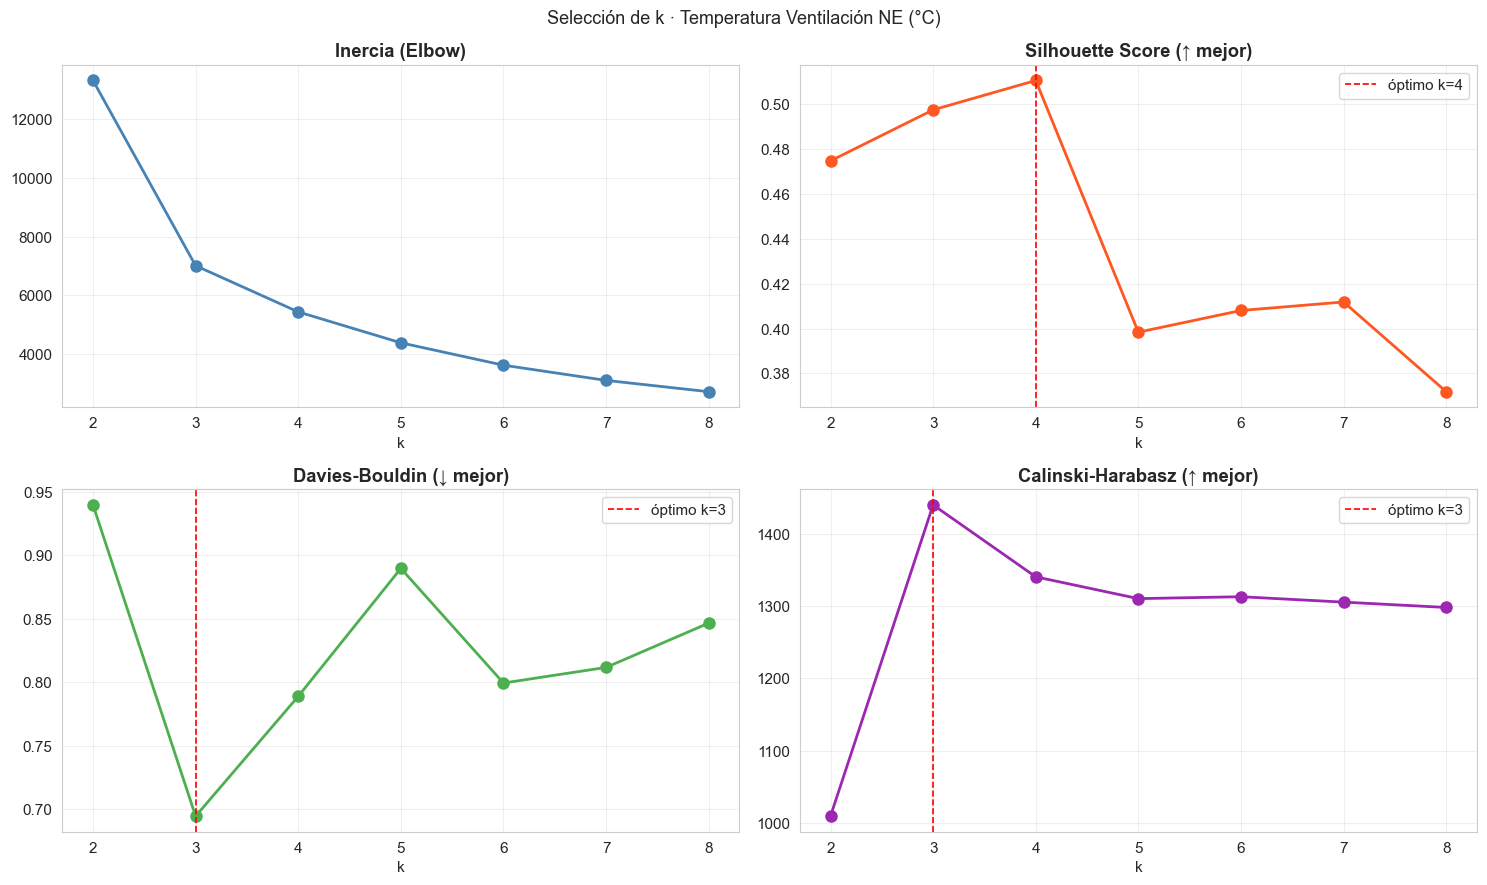

      inertia  silhouette  davies_bouldin  calinski_harabasz
k                                                           
2  13315.6587      0.4748          0.9396          1008.8843
3   7006.8927      0.4975          0.6945          1440.7782
4   5433.4159      0.5107          0.7888          1341.0045
5   4380.3350      0.3984          0.8896          1310.7539
6   3618.1432      0.4080          0.7993          1313.3956
7   3100.2271      0.4118          0.8116          1305.9104
8   2715.2298      0.3718          0.8465          1298.5045

→ k óptimo para Temperatura (por Silhouette): k = 4


In [17]:
scaler_tmp = StandardScaler()
Xs_tmp = scaler_tmp.fit_transform(X_tmp)

metrics_tmp = select_k(Xs_tmp)
plot_k_selection(metrics_tmp, LBL_TMP, 'B7_TMP_k_selection.png')
print(metrics_tmp.round(4))

K_TMP = int(metrics_tmp['silhouette'].idxmax())
print(f'\n→ k óptimo para Temperatura (por Silhouette): k = {K_TMP}')


  Temperatura · Consistencia (ARI):
         K-Means    Ward     GMM
K-Means   1.0000  0.8440  0.2845
Ward      0.8440  1.0000  0.2749
GMM       0.2845  0.2749  1.0000


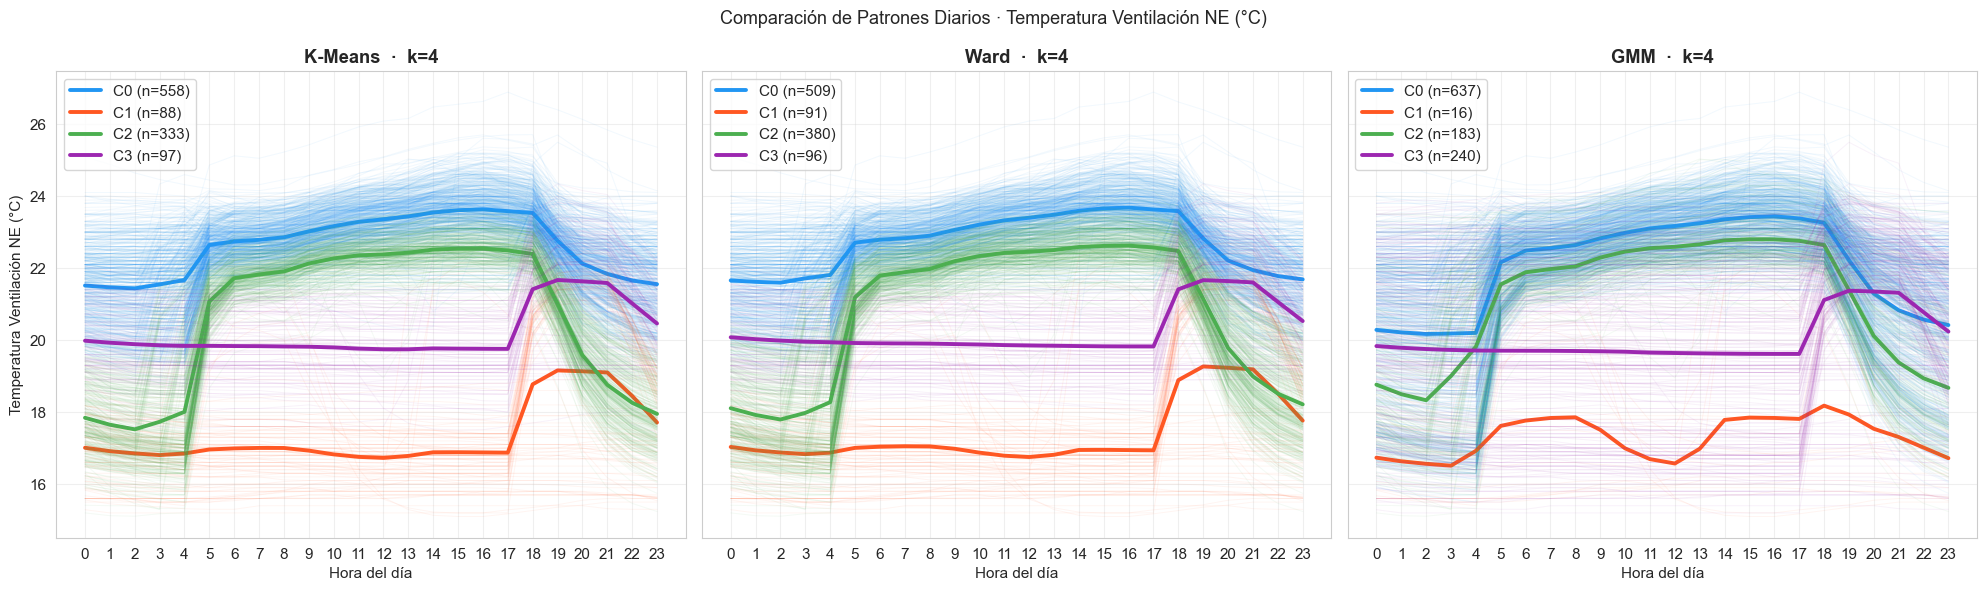

In [18]:
sns.set_style('whitegrid')
clust_tmp = run_three_clusterings(Xs_tmp, K_TMP)
lbl_km_t  = clust_tmp['kmeans']
lbl_war_t = align_labels_to_kmeans(lbl_km_t, clust_tmp['ward'], K_TMP)
lbl_gmm_t = align_labels_to_kmeans(lbl_km_t, clust_tmp['gmm'],  K_TMP)

cents_km_t  = np.array([X_tmp[lbl_km_t == c].mean(0)  for c in range(K_TMP)])
cents_war_t = np.array([X_tmp[lbl_war_t == c].mean(0) for c in range(K_TMP)])
cents_gmm_t = np.array([X_tmp[lbl_gmm_t == c].mean(0) for c in range(K_TMP)])

ari_t = pd.DataFrame({
    'K-Means': [1.0,
                adjusted_rand_score(lbl_km_t, lbl_war_t),
                adjusted_rand_score(lbl_km_t, lbl_gmm_t)],
    'Ward':    [adjusted_rand_score(lbl_km_t, lbl_war_t), 1.0,
                adjusted_rand_score(lbl_war_t, lbl_gmm_t)],
    'GMM':     [adjusted_rand_score(lbl_km_t, lbl_gmm_t),
                adjusted_rand_score(lbl_war_t, lbl_gmm_t), 1.0]
}, index=['K-Means','Ward','GMM'])

print(f'\n  Temperatura · Consistencia (ARI):')
print(ari_t.round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
for ax, (name, lbls, cents) in zip(axes, [('K-Means',lbl_km_t,cents_km_t),
                                            ('Ward',lbl_war_t,cents_war_t),
                                            ('GMM',lbl_gmm_t,cents_gmm_t)]):
    for c in range(K_TMP):
        m = lbls == c
        for row in X_tmp[m]:
            ax.plot(HOURS, row, color=PALETTE[c], alpha=0.06, lw=0.7)
        ax.plot(HOURS, cents[c], color=PALETTE[c], lw=2.8, label=f'C{c} (n={m.sum()})')
    ax.set_title(f'{name}  ·  k={K_TMP}', fontweight='bold')
    ax.set_xlabel('Hora del día'); ax.set_xticks(HOURS); ax.legend(loc='upper left')
axes[0].set_ylabel(LBL_TMP)
plt.suptitle(f'Comparación de Patrones Diarios · {LBL_TMP}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/B8_TMP_centroides_3tec.png', dpi=140, bbox_inches='tight')
plt.show()

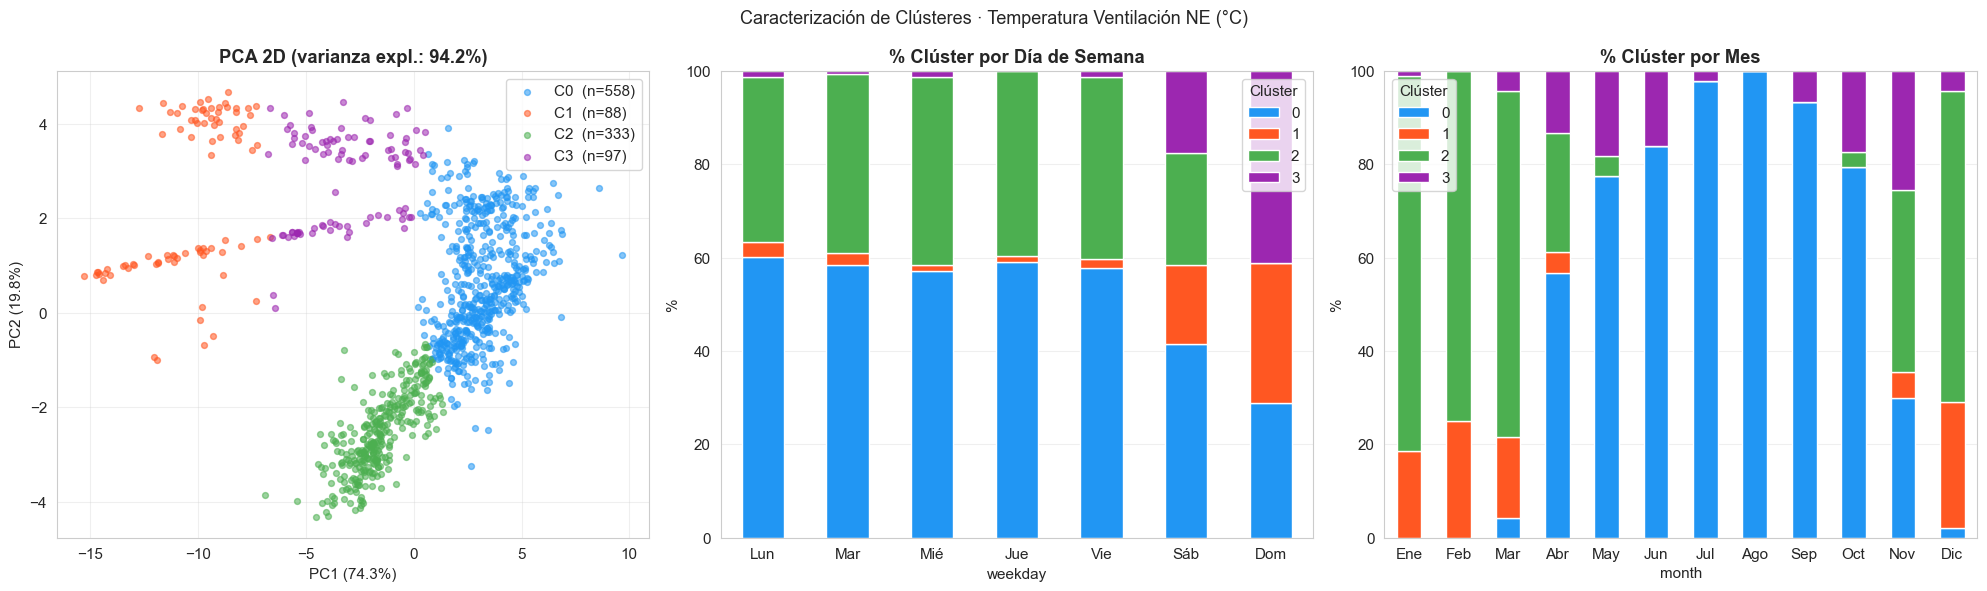

✓ 24/24 horas con diferencias significativas (ANOVA p<0.05).


In [19]:
sns.set_style('whitegrid')
pca_tmp = PCA(n_components=2, random_state=RND)
Xp_tmp = pca_tmp.fit_transform(Xs_tmp)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for c in range(K_TMP):
    m = lbl_km_t == c
    axes[0].scatter(Xp_tmp[m, 0], Xp_tmp[m, 1], color=PALETTE[c], alpha=0.55,
                    s=18, label=f'C{c}  (n={m.sum()})')
axes[0].set_title(f'PCA 2D (varianza expl.: {pca_tmp.explained_variance_ratio_.sum()*100:.1f}%)')
axes[0].set_xlabel(f'PC1 ({pca_tmp.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_tmp.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

df_lbl_tmp = pd.DataFrame({'cluster': lbl_km_t, 'weekday': dates_tmp.weekday,
                            'month': dates_tmp.month})
ct_wd_t = pd.crosstab(df_lbl_tmp['weekday'], df_lbl_tmp['cluster'], normalize='index')*100
ct_wd_t.plot(kind='bar', stacked=True, ax=axes[1],
             color=[PALETTE[c] for c in ct_wd_t.columns], edgecolor='white')
axes[1].set_title('% Clúster por Día de Semana', fontweight='bold')
axes[1].set_xticklabels(['Lun','Mar','Mié','Jue','Vie','Sáb','Dom'], rotation=0)
axes[1].set_ylabel('%'); axes[1].legend(title='Clúster')

ct_m_t = pd.crosstab(df_lbl_tmp['month'], df_lbl_tmp['cluster'], normalize='index')*100
ct_m_t.plot(kind='bar', stacked=True, ax=axes[2],
            color=[PALETTE[c] for c in ct_m_t.columns], edgecolor='white')
axes[2].set_title('% Clúster por Mes', fontweight='bold')
axes[2].set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'], rotation=0)
axes[2].set_ylabel('%'); axes[2].legend(title='Clúster')

plt.suptitle(f'Caracterización de Clústeres · {LBL_TMP}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/B9_TMP_pca_y_calendar.png', dpi=140, bbox_inches='tight')
plt.show()

pvals_tmp = anova_by_hour(X_tmp, lbl_km_t, K_TMP)
n_sig_t   = (pvals_tmp < 0.05).sum()
print(f'✓ {n_sig_t}/24 horas con diferencias significativas (ANOVA p<0.05).')

### B.6 · Interpretación comparativa

**CO2:**
- Si la matriz ARI ≥ 0.7 → las 3 técnicas convergen, los patrones son **robustos**.
- Distribución por día de semana revela que los clústeres separan claramente **fines de semana de laborables**.
- ANOVA significativo en la gran mayoría de horas → diferencias **no son al azar**.

**Temperatura:**
- Los clústeres se asocian más al **mes** (estacionalidad climática) que al día de semana.
- Reflejo de que la temperatura responde al **clima externo**, no a la ocupación.

**Esta es una diferencia conceptual importante:** el aprendizaje no supervisado descubrió **dos fenómenos distintos** que gobiernan cada variable: ocupación (CO2) y estacionalidad (temperatura).

---
# Literal C · Anomalías — Análisis Univariable

**Objetivo del taller:** *"Es posible que ciertos perfiles diarios en el set de datos no pertenezcan a los patrones diarios descubiertos en el literal B. ¿Cómo detectarlos?"*

### Estrategia: 3 métodos complementarios

| # | Método | Tipo | Fundamento |
|---|---|---|---|
| 1 | **Distancia al centroide** (μ + 2σ) | Basado en clúster | Día atípico si está lejos del centroide asignado |
| 2 | **Isolation Forest** | Basado en árboles | Aísla puntos en pocas particiones aleatorias |
| 3 | **Local Outlier Factor (LOF)** | Basado en densidad | Compara densidad local con vecinos |

Una anomalía es **robusta** si la detectan **≥2 métodos** (consenso).

In [20]:
def detect_anomalies(X_orig, X_scaled, km_obj, contamination=0.05):
    """Aplica 3 métodos de detección de anomalías."""
    labels = km_obj.labels_
    # M1 · Distancia al centroide asignado
    dists = cdist(X_scaled, km_obj.cluster_centers_)
    min_d = dists[np.arange(len(X_scaled)), labels]
    thr   = min_d.mean() + 2 * min_d.std()
    a_dist = min_d > thr

    # M2 · Isolation Forest
    iso = IsolationForest(n_estimators=200, contamination=contamination,
                          random_state=RND, n_jobs=-1).fit(X_scaled)
    a_iso  = iso.predict(X_scaled) == -1
    score_iso = iso.decision_function(X_scaled)

    # M3 · Local Outlier Factor
    lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination, n_jobs=-1)
    a_lof  = lof.fit_predict(X_scaled) == -1
    score_lof = -lof.negative_outlier_factor_

    consensus = (a_dist.astype(int) + a_iso.astype(int) + a_lof.astype(int))
    return dict(dist=a_dist, iso=a_iso, lof=a_lof,
                min_d=min_d, thr=thr,
                score_iso=score_iso, score_lof=score_lof,
                consensus=consensus)

## C.1 · CO2 · Detección con 3 métodos

In [21]:
anom_co2 = detect_anomalies(X_co2, Xs_co2, clust_co2['km_obj'])

rep = pd.DataFrame({
    'Método': ['Distancia μ+2σ','Isolation Forest','Local Outlier Factor'],
    'N anomalías':  [int(anom_co2['dist'].sum()),
                     int(anom_co2['iso'].sum()),
                     int(anom_co2['lof'].sum())],
    '% del total': [f"{anom_co2['dist'].mean()*100:.1f}%",
                    f"{anom_co2['iso'].mean()*100:.1f}%",
                    f"{anom_co2['lof'].mean()*100:.1f}%"]
})
print(f'\n  CO2 · Anomalías detectadas (sobre {len(X_co2)} días):')
print(rep.to_string(index=False))
print(f'\n  Consenso:')
for v in range(4):
    print(f'   detectado por exactamente {v} método(s): {int((anom_co2["consensus"]==v).sum())}')
robust_co2 = anom_co2['consensus'] >= 2
print(f'\n  → ANOMALÍAS ROBUSTAS (≥2 métodos): {int(robust_co2.sum())} días')


  CO2 · Anomalías detectadas (sobre 1079 días):
              Método  N anomalías % del total
      Distancia μ+2σ           51        4.7%
    Isolation Forest           54        5.0%
Local Outlier Factor           54        5.0%

  Consenso:
   detectado por exactamente 0 método(s): 997
   detectado por exactamente 1 método(s): 33
   detectado por exactamente 2 método(s): 21
   detectado por exactamente 3 método(s): 28

  → ANOMALÍAS ROBUSTAS (≥2 métodos): 49 días


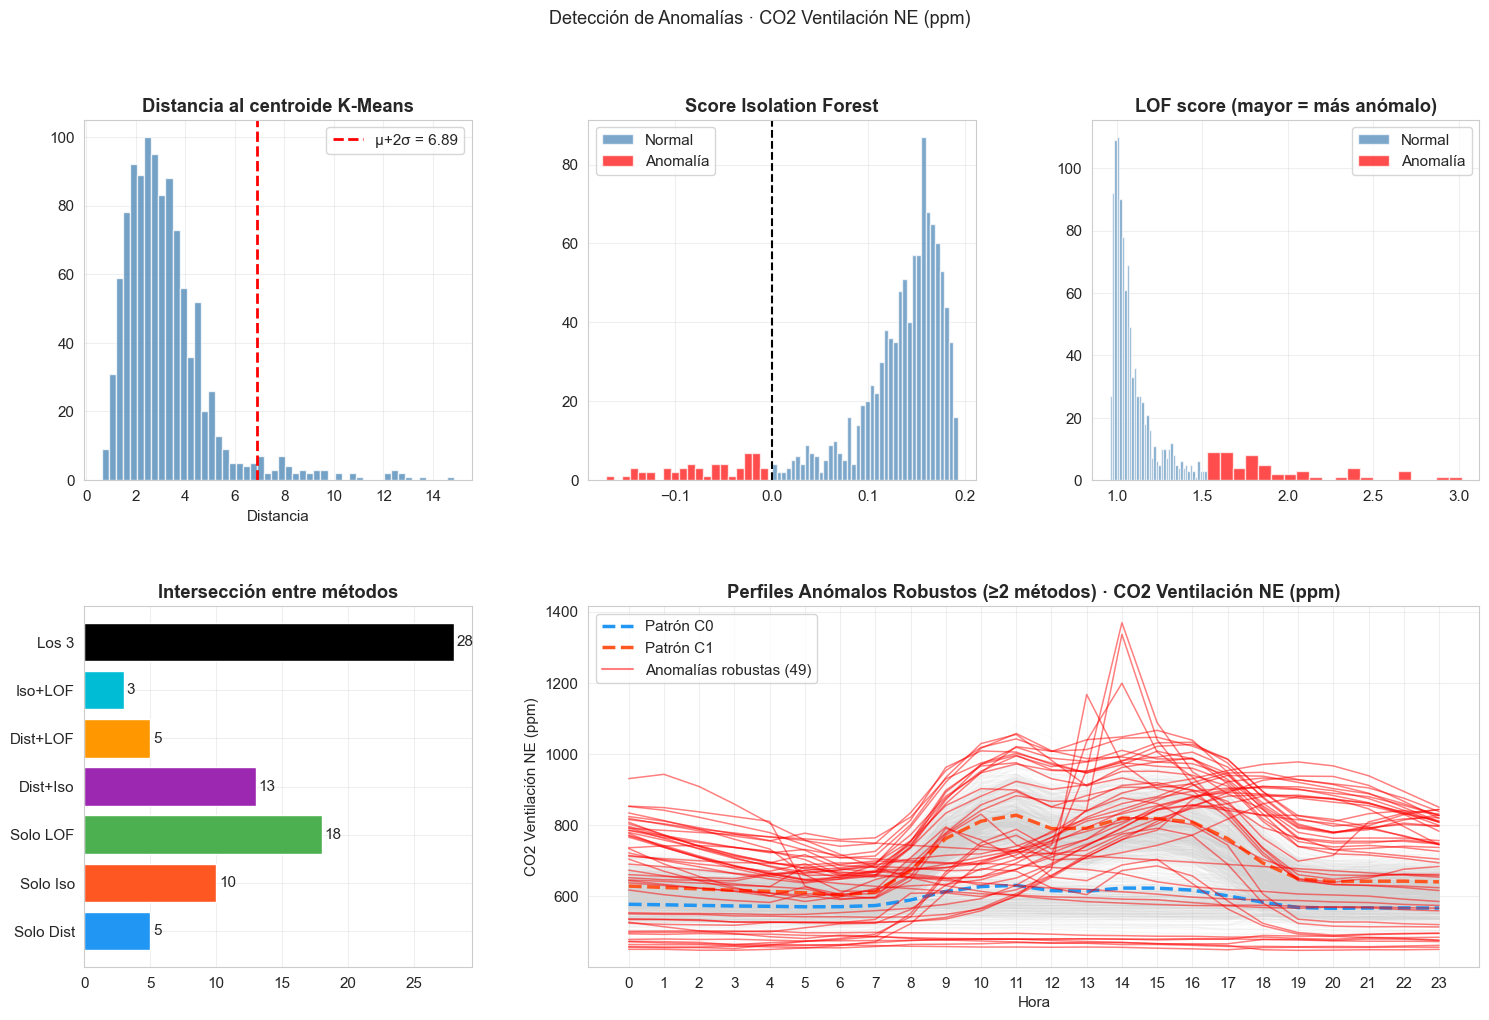

In [22]:
sns.set_style('whitegrid')
# Visualización: 4 paneles
fig = plt.figure(figsize=(18, 11))
gs  = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.30)

# (1) Histograma distancia
ax = fig.add_subplot(gs[0, 0])
ax.hist(anom_co2['min_d'], bins=50, color='steelblue', alpha=0.75, edgecolor='white')
ax.axvline(anom_co2['thr'], color='red', ls='--', lw=2, label=f'μ+2σ = {anom_co2["thr"]:.2f}')
ax.set_title('Distancia al centroide K-Means', fontweight='bold'); ax.set_xlabel('Distancia'); ax.legend()

# (2) Score Isolation Forest
ax = fig.add_subplot(gs[0, 1])
ax.hist(anom_co2['score_iso'][~anom_co2['iso']], bins=40, color='steelblue', alpha=0.7, label='Normal')
ax.hist(anom_co2['score_iso'][anom_co2['iso']],  bins=20, color='red',       alpha=0.7, label='Anomalía')
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.set_title('Score Isolation Forest', fontweight='bold'); ax.legend()

# (3) Score LOF
ax = fig.add_subplot(gs[0, 2])
ax.hist(anom_co2['score_lof'][~anom_co2['lof']], bins=40, color='steelblue', alpha=0.7, label='Normal')
ax.hist(anom_co2['score_lof'][anom_co2['lof']],  bins=20, color='red',       alpha=0.7, label='Anomalía')
ax.set_title('LOF score (mayor = más anómalo)', fontweight='bold'); ax.legend()

# (4) Diagrama de Venn manual de coincidencias
ax = fig.add_subplot(gs[1, 0])
venn_data = {
    'Solo Dist': int(((anom_co2['dist']) & (~anom_co2['iso']) & (~anom_co2['lof'])).sum()),
    'Solo Iso':  int((~anom_co2['dist'] & anom_co2['iso']  & ~anom_co2['lof']).sum()),
    'Solo LOF':  int((~anom_co2['dist'] & ~anom_co2['iso'] & anom_co2['lof']).sum()),
    'Dist+Iso':  int((anom_co2['dist'] & anom_co2['iso']  & ~anom_co2['lof']).sum()),
    'Dist+LOF':  int((anom_co2['dist'] & ~anom_co2['iso'] & anom_co2['lof']).sum()),
    'Iso+LOF':   int((~anom_co2['dist'] & anom_co2['iso'] & anom_co2['lof']).sum()),
    'Los 3':     int((anom_co2['dist'] & anom_co2['iso']  & anom_co2['lof']).sum())
}
ax.barh(list(venn_data.keys()), list(venn_data.values()),
        color=['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800','#00BCD4','black'])
ax.set_title('Intersección entre métodos', fontweight='bold')
for i, v in enumerate(venn_data.values()):
    ax.text(v+0.2, i, str(v), va='center')

# (5) Perfiles anómalos robustos vs centroides
ax = fig.add_subplot(gs[1, 1:])
for row in X_co2[~robust_co2]:
    ax.plot(HOURS, row, color='lightgray', alpha=0.10, lw=0.6)
for c in range(K_CO2):
    ax.plot(HOURS, centroids_km[c], color=PALETTE[c], lw=2.5, ls='--',
            label=f'Patrón C{c}')
for row in X_co2[robust_co2]:
    ax.plot(HOURS, row, color='red', alpha=0.5, lw=1.1)
ax.plot([], [], color='red', alpha=0.5, lw=1.5, label=f'Anomalías robustas ({robust_co2.sum()})')
ax.set_title(f'Perfiles Anómalos Robustos (≥2 métodos) · {LBL_CO2}', fontweight='bold')
ax.set_xlabel('Hora'); ax.set_ylabel(LBL_CO2); ax.set_xticks(HOURS); ax.legend(loc='upper left')

plt.suptitle(f'Detección de Anomalías · {LBL_CO2}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/C1_CO2_anomalias.png', dpi=140, bbox_inches='tight')
plt.show()

### C.2 Explicación horaria de las anomalías

**¿QUÉ horas hacen anómalo a un día?** Calculamos para cada día anómalo la **desviación z-score** respecto al centroide asignado, hora por hora. Las horas con |z| más alto son las que **explican** la anomalía.

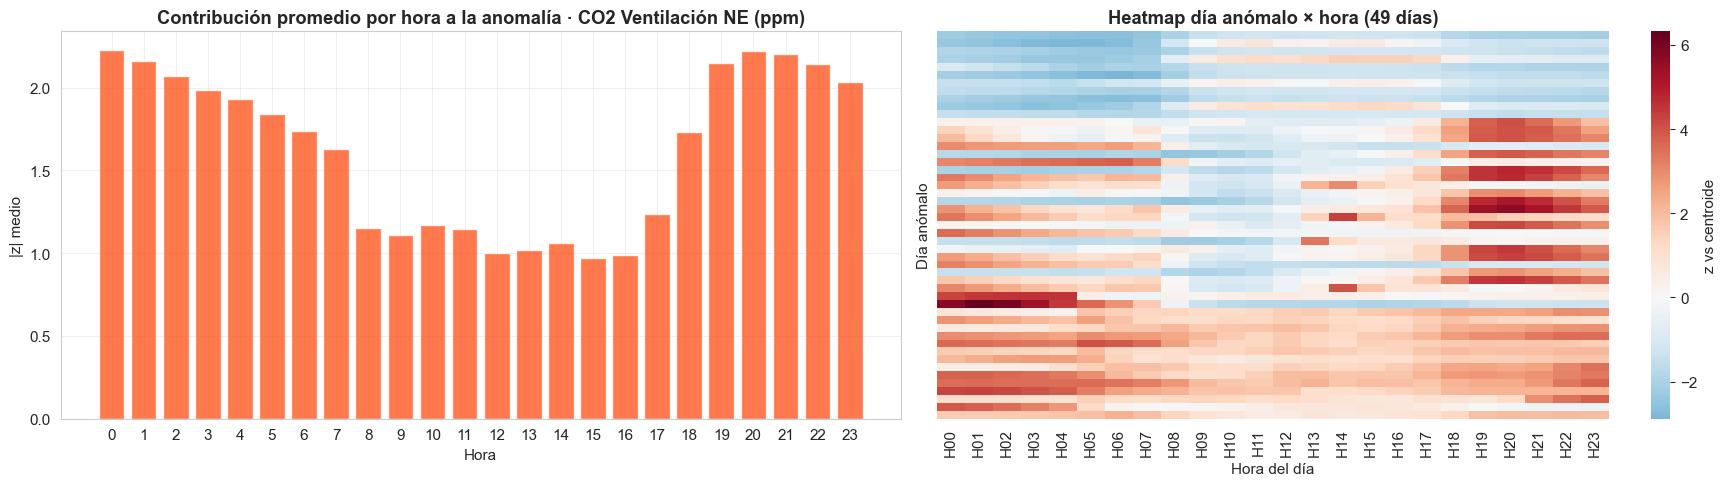


Top 5 horas que más contribuyen a las anomalías CO2: ['H00 (2.23)', 'H20 (2.22)', 'H21 (2.21)', 'H01 (2.16)', 'H19 (2.15)']


In [23]:
sns.set_style('whitegrid')
def hourly_contribution(X, labels, centroids, anomaly_mask):
    """Devuelve matriz (n_anom, 24) con desviaciones estandarizadas vs centroide."""
    if anomaly_mask.sum() == 0:
        return np.zeros((0, 24))
    cent_assigned = centroids[labels[anomaly_mask]]
    diff = X[anomaly_mask] - cent_assigned
    std_h = X.std(axis=0)
    return diff / std_h

contrib_co2 = hourly_contribution(X_co2, lbl_km, centroids_km, robust_co2)
mean_contrib_co2 = np.mean(np.abs(contrib_co2), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].bar(HOURS, mean_contrib_co2, color='#FF5722', alpha=0.8)
axes[0].set_title(f'Contribución promedio por hora a la anomalía · {LBL_CO2}', fontweight='bold')
axes[0].set_xlabel('Hora'); axes[0].set_ylabel('|z| medio'); axes[0].set_xticks(HOURS)

if contrib_co2.shape[0] > 0:
    sns.heatmap(contrib_co2, cmap='RdBu_r', center=0, ax=axes[1],
                cbar_kws={'label':'z vs centroide'},
                xticklabels=[f'H{h:02d}' for h in HOURS], yticklabels=False)
    axes[1].set_title(f'Heatmap día anómalo × hora ({contrib_co2.shape[0]} días)', fontweight='bold')
    axes[1].set_xlabel('Hora del día'); axes[1].set_ylabel('Día anómalo')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/C2_CO2_explain.png', dpi=140, bbox_inches='tight')
plt.show()

top_hours = np.argsort(mean_contrib_co2)[::-1][:5]
print(f'\nTop 5 horas que más contribuyen a las anomalías CO2: '
      f"{[f'H{h:02d} ({mean_contrib_co2[h]:.2f})' for h in top_hours]}")

### C.3 · CO2 · Top 6 perfiles más anómalos (zoom)

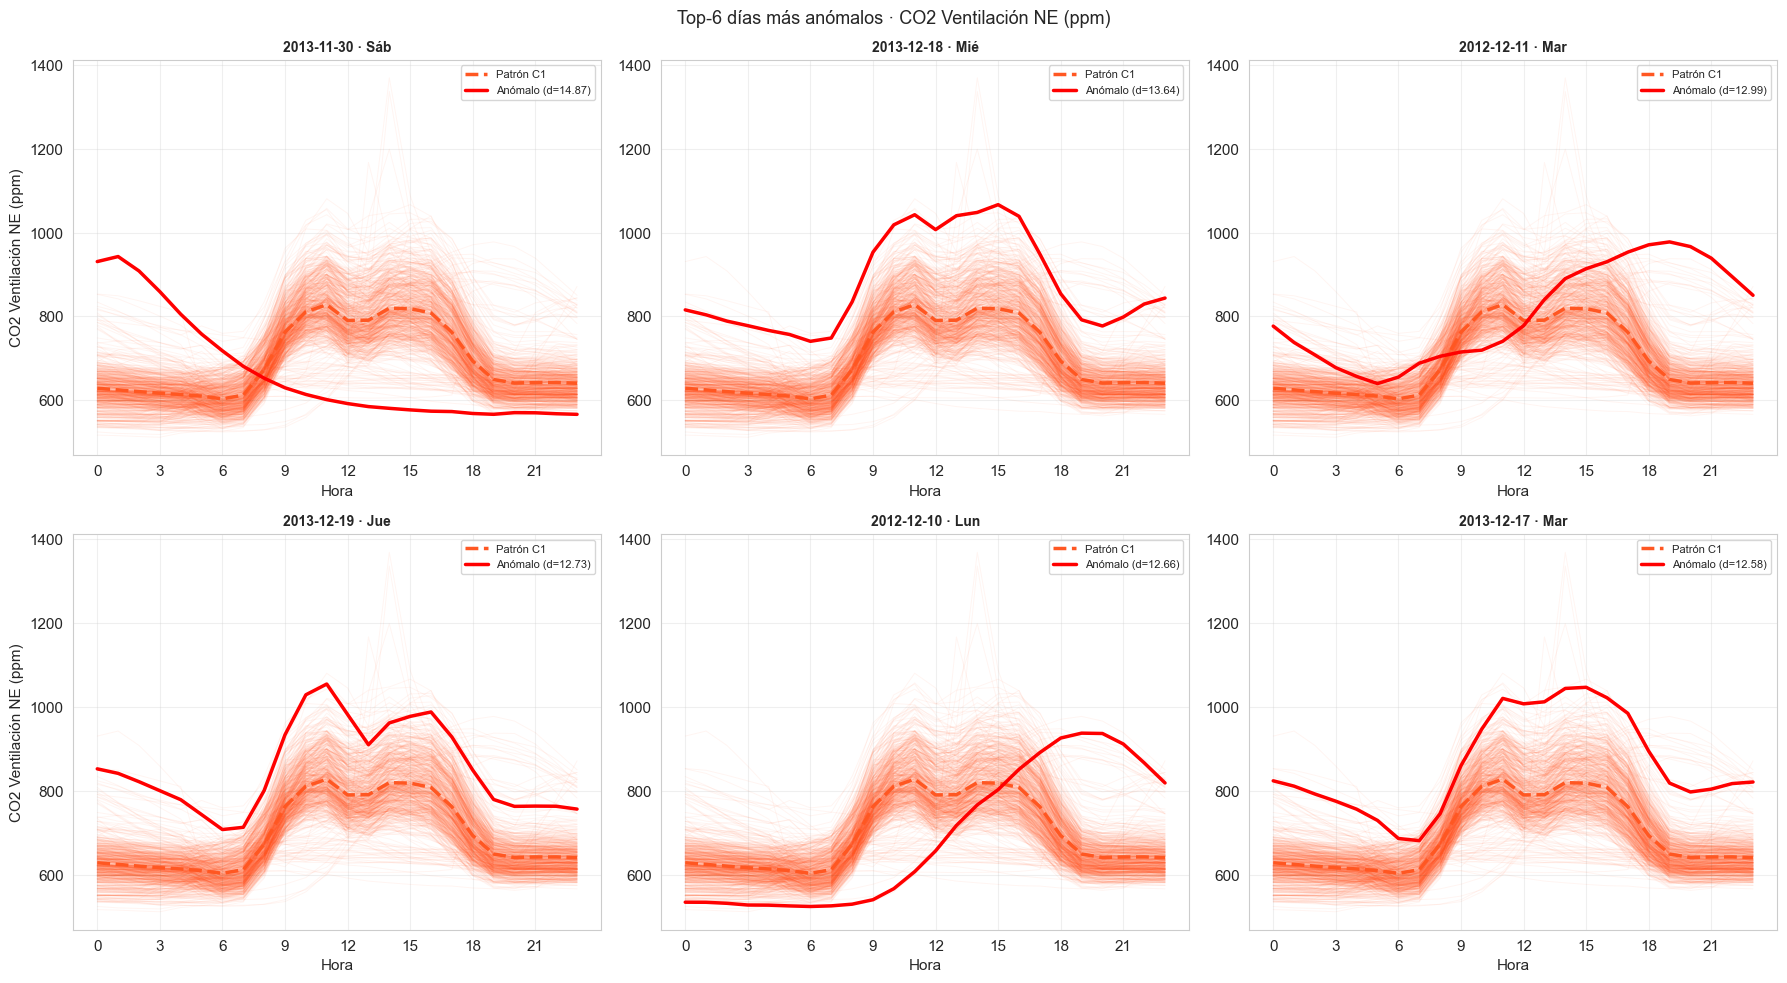

In [24]:
sns.set_style('whitegrid')
top_idx = np.argsort(anom_co2['min_d'])[::-1][:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, idx in enumerate(top_idx):
    ax = axes.flat[i]
    cl_assigned = lbl_km[idx]
    for row in X_co2[lbl_km == cl_assigned]:
        ax.plot(HOURS, row, color=PALETTE[cl_assigned], alpha=0.06, lw=0.7)
    ax.plot(HOURS, centroids_km[cl_assigned], color=PALETTE[cl_assigned],
            lw=2.5, ls='--', label=f'Patrón C{cl_assigned}')
    ax.plot(HOURS, X_co2[idx], color='red', lw=2.5,
            label=f'Anómalo (d={anom_co2["min_d"][idx]:.2f})')
    weekday = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom'][dates_co2[idx].weekday()]
    ax.set_title(f'{dates_co2[idx].date()} · {weekday}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Hora'); ax.set_xticks(HOURS[::3]); ax.legend(fontsize=8)
axes[0,0].set_ylabel(LBL_CO2); axes[1,0].set_ylabel(LBL_CO2)
plt.suptitle(f'Top-6 días más anómalos · {LBL_CO2}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/C3_CO2_top6.png', dpi=140, bbox_inches='tight')
plt.show()

## C.4 · Temperatura · Detección con 3 métodos

In [25]:
anom_tmp = detect_anomalies(X_tmp, Xs_tmp, clust_tmp['km_obj'])
robust_tmp = anom_tmp['consensus'] >= 2

rep_t = pd.DataFrame({
    'Método': ['Distancia μ+2σ','Isolation Forest','Local Outlier Factor'],
    'N': [int(anom_tmp['dist'].sum()), int(anom_tmp['iso'].sum()), int(anom_tmp['lof'].sum())],
    '%': [f"{anom_tmp['dist'].mean()*100:.1f}%",
          f"{anom_tmp['iso'].mean()*100:.1f}%",
          f"{anom_tmp['lof'].mean()*100:.1f}%"]
})
print(f'  Temperatura · Anomalías detectadas (sobre {len(X_tmp)} días):')
print(rep_t.to_string(index=False))
print(f'  → Anomalías ROBUSTAS (≥2 métodos): {int(robust_tmp.sum())} días')

  Temperatura · Anomalías detectadas (sobre 1076 días):
              Método  N    %
      Distancia μ+2σ 36 3.3%
    Isolation Forest 54 5.0%
Local Outlier Factor 54 5.0%
  → Anomalías ROBUSTAS (≥2 métodos): 31 días


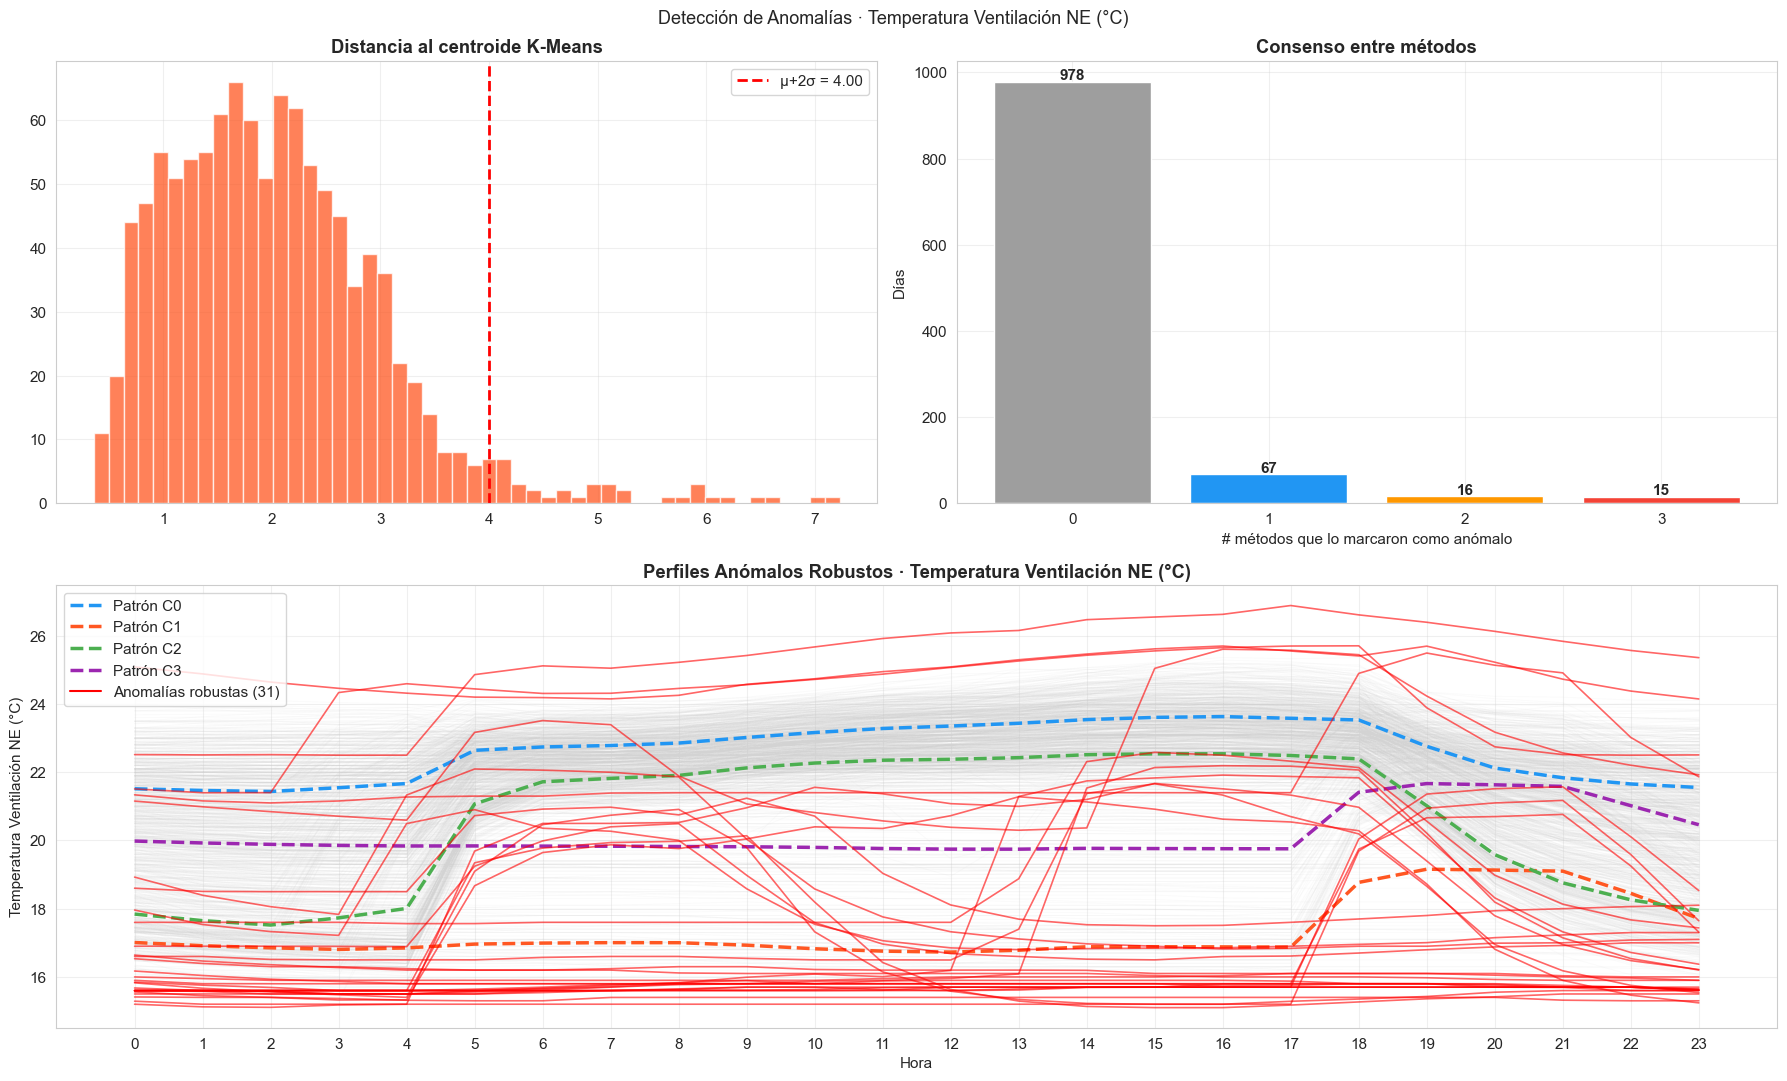

In [26]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(18, 11))

# Histograma distancias
ax = axes[0, 0]
ax.hist(anom_tmp['min_d'], bins=50, color='#FF5722', alpha=0.75, edgecolor='white')
ax.axvline(anom_tmp['thr'], color='red', ls='--', lw=2, label=f'μ+2σ = {anom_tmp["thr"]:.2f}')
ax.set_title('Distancia al centroide K-Means', fontweight='bold'); ax.legend()

# Distribución de consensos
ax = axes[0, 1]
counts = np.bincount(anom_tmp['consensus'], minlength=4)
ax.bar(range(4), counts, color=['#9E9E9E','#2196F3','#FF9800','#F44336'])
for i, v in enumerate(counts):
    ax.text(i, v+5, str(v), ha='center', fontweight='bold')
ax.set_xticks(range(4)); ax.set_xlabel('# métodos que lo marcaron como anómalo')
ax.set_ylabel('Días'); ax.set_title('Consenso entre métodos', fontweight='bold')

# Perfiles anómalos vs centroides
ax = axes[1, :].ravel()[0]
axes[1, 0].remove(); axes[1, 1].remove()
ax = fig.add_subplot(2, 1, 2)
for row in X_tmp[~robust_tmp]:
    ax.plot(HOURS, row, color='lightgray', alpha=0.10, lw=0.6)
for c in range(K_TMP):
    ax.plot(HOURS, cents_km_t[c], color=PALETTE[c], lw=2.5, ls='--', label=f'Patrón C{c}')
for row in X_tmp[robust_tmp]:
    ax.plot(HOURS, row, color='red', alpha=0.6, lw=1.2)
ax.plot([], [], color='red', lw=1.5, label=f'Anomalías robustas ({robust_tmp.sum()})')
ax.set_title(f'Perfiles Anómalos Robustos · {LBL_TMP}', fontweight='bold')
ax.set_xlabel('Hora'); ax.set_ylabel(LBL_TMP); ax.set_xticks(HOURS); ax.legend(loc='upper left')

plt.suptitle(f'Detección de Anomalías · {LBL_TMP}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/C4_TMP_anomalias.png', dpi=140, bbox_inches='tight')
plt.show()

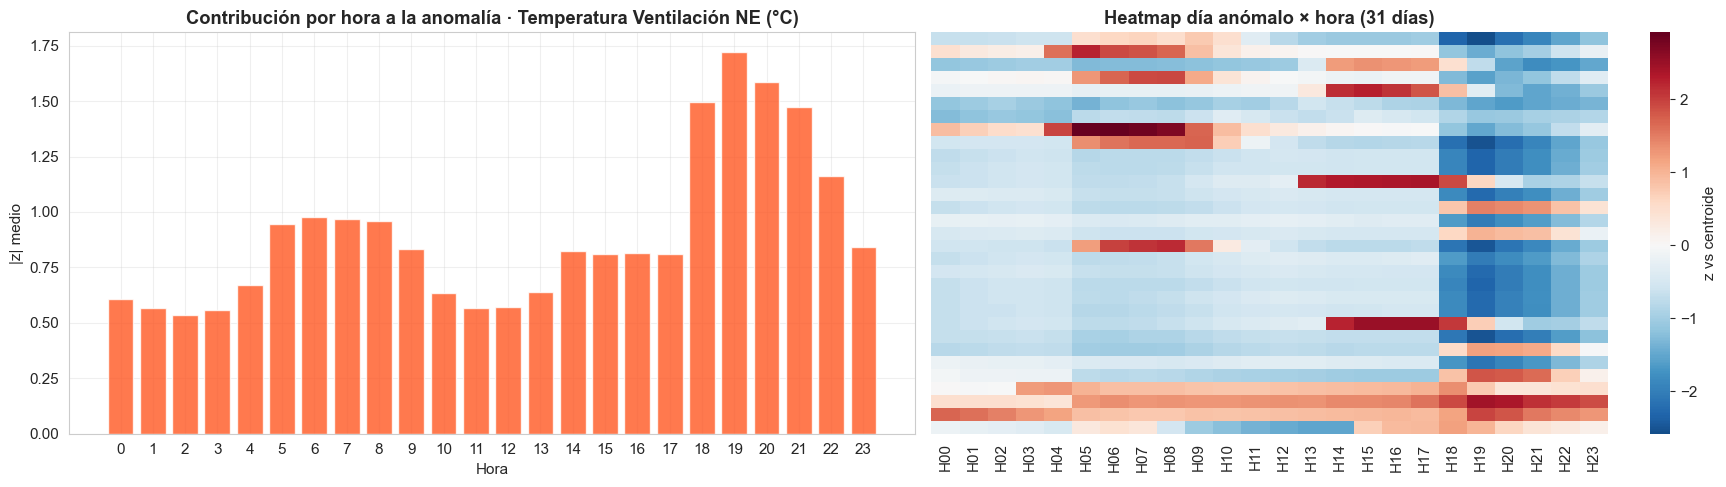

In [27]:
sns.set_style('whitegrid')
contrib_tmp = hourly_contribution(X_tmp, lbl_km_t, cents_km_t, robust_tmp)
mean_contrib_tmp = np.mean(np.abs(contrib_tmp), axis=0) if contrib_tmp.shape[0]>0 else np.zeros(24)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].bar(HOURS, mean_contrib_tmp, color='#FF5722', alpha=0.8)
axes[0].set_title(f'Contribución por hora a la anomalía · {LBL_TMP}', fontweight='bold')
axes[0].set_xlabel('Hora'); axes[0].set_ylabel('|z| medio'); axes[0].set_xticks(HOURS)

if contrib_tmp.shape[0] > 0:
    sns.heatmap(contrib_tmp, cmap='RdBu_r', center=0, ax=axes[1],
                cbar_kws={'label':'z vs centroide'},
                xticklabels=[f'H{h:02d}' for h in HOURS], yticklabels=False)
    axes[1].set_title(f'Heatmap día anómalo × hora ({contrib_tmp.shape[0]} días)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/C5_TMP_explain.png', dpi=140, bbox_inches='tight')
plt.show()


# Análisis Cruzado CO2 ↔ Temperatura

Aunque el taller solicita análisis univariable, **cruzar** las anomalías de las dos variables univariables aporta insight adicional: ¿los días anómalos en CO2 coinciden con los anómalos en temperatura? Si sí, sugiere un evento sistémico (fallo del sistema, cierre del edificio, etc.). Si no, sugiere causas independientes.

In [28]:
# Alineamos por fecha
df_co2 = pd.DataFrame({'date': dates_co2.date, 'anom_co2': robust_co2})
df_tmp = pd.DataFrame({'date': dates_tmp.date, 'anom_tmp': robust_tmp})
merged = df_co2.merge(df_tmp, on='date', how='inner')

n_both = int((merged['anom_co2'] & merged['anom_tmp']).sum())
n_only_co2 = int((merged['anom_co2'] & ~merged['anom_tmp']).sum())
n_only_tmp = int((~merged['anom_co2'] & merged['anom_tmp']).sum())
n_normal   = int((~merged['anom_co2'] & ~merged['anom_tmp']).sum())

print('═'*55)
print('  Cruce de anomalías CO2 ↔ Temperatura')
print('═'*55)
print(f'  Días normales en ambas        : {n_normal:>5}')
print(f'  Solo CO2 anómalo               : {n_only_co2:>5}')
print(f'  Solo Temperatura anómala       : {n_only_tmp:>5}')
print(f'  Anómalos en AMBAS variables    : {n_both:>5}  ← candidatos a evento sistémico')

# Coeficiente phi (correlación binaria)
n = len(merged)
p_co2 = merged['anom_co2'].mean(); p_tmp = merged['anom_tmp'].mean()
p_both = (merged['anom_co2'] & merged['anom_tmp']).mean()
phi = (p_both - p_co2*p_tmp) / np.sqrt(p_co2*(1-p_co2)*p_tmp*(1-p_tmp) + 1e-12)
print(f'\n  Coeficiente de asociación φ = {phi:.4f}')
if phi > 0.2:
    print('  → Asociación moderada/fuerte: hay relación entre ambas anomalías.')
elif phi > 0.05:
    print('  → Asociación débil: las anomalías son mayormente independientes.')
else:
    print('  → Sin asociación: anomalías totalmente independientes.')

═══════════════════════════════════════════════════════
  Cruce de anomalías CO2 ↔ Temperatura
═══════════════════════════════════════════════════════
  Días normales en ambas        :  1010
  Solo CO2 anómalo               :    35
  Solo Temperatura anómala       :    17
  Anómalos en AMBAS variables    :    14  ← candidatos a evento sistémico

  Coeficiente de asociación φ = 0.3355
  → Asociación moderada/fuerte: hay relación entre ambas anomalías.


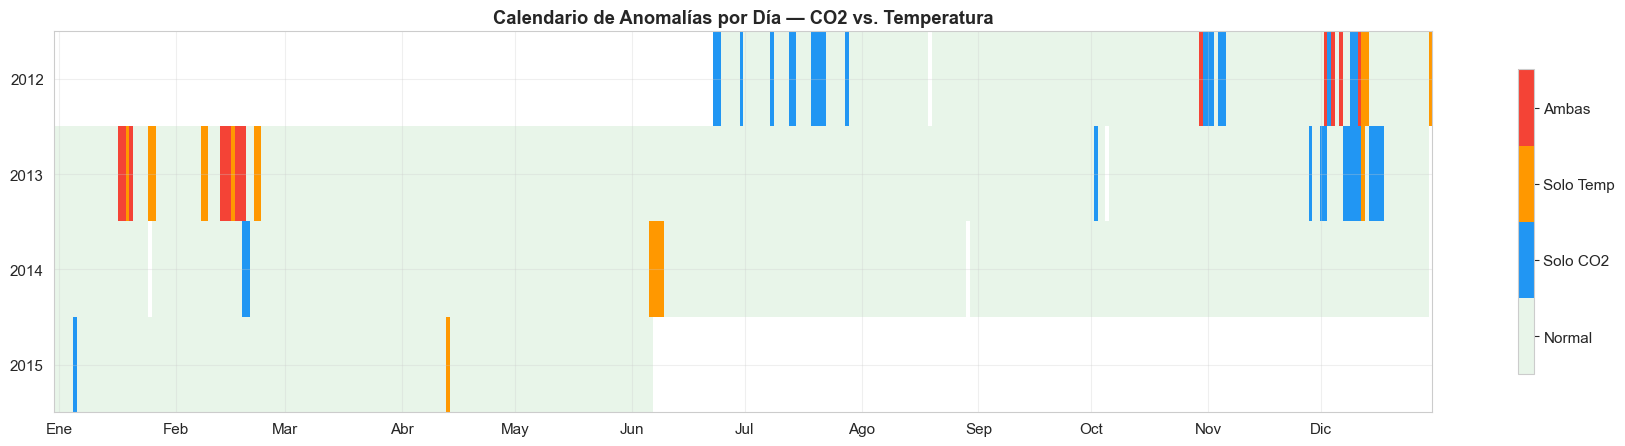

In [29]:
sns.set_style('whitegrid')
# Calendario tipo heatmap: filas = años, columnas = día del año
merged['date_dt'] = pd.to_datetime(merged['date'])
merged['year'] = merged['date_dt'].dt.year
merged['doy']  = merged['date_dt'].dt.dayofyear

merged['status'] = 0
merged.loc[merged['anom_co2'] & ~merged['anom_tmp'], 'status'] = 1
merged.loc[~merged['anom_co2'] & merged['anom_tmp'], 'status'] = 2
merged.loc[merged['anom_co2'] & merged['anom_tmp'],  'status'] = 3

years = sorted(merged['year'].unique())
cal = np.full((len(years), 366), np.nan)
for i, y in enumerate(years):
    sub = merged[merged['year']==y]
    for _, r in sub.iterrows():
        cal[i, r['doy']-1] = r['status']

cmap = mcolors.ListedColormap(['#E8F5E9','#2196F3','#FF9800','#F44336'])
fig, ax = plt.subplots(figsize=(18, 2.2 + len(years)*0.6))
im = ax.imshow(cal, aspect='auto', cmap=cmap, vmin=-0.5, vmax=3.5)
ax.set_yticks(range(len(years))); ax.set_yticklabels(years)
month_start = [pd.Timestamp(f'2020-{m:02d}-01').dayofyear for m in range(1,13)]
ax.set_xticks(month_start)
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
ax.set_title('Calendario de Anomalías por Día — CO2 vs. Temperatura', fontweight='bold')

cbar = plt.colorbar(im, ax=ax, ticks=[0,1,2,3], shrink=0.8)
cbar.ax.set_yticklabels(['Normal','Solo CO2','Solo Temp','Ambas'])
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/PLUS_calendar.png', dpi=140, bbox_inches='tight')
plt.show()

---
# D · Resumen Cuantitativo de Resultados

In [30]:
summary = pd.DataFrame({
    LBL_CO2: [
        f'{X_co2.shape[0]} días',
        f'k = {K_CO2}',
        f'{silhouette_score(Xs_co2, lbl_km):.3f}',
        f'{ari_matrix.loc["K-Means","Ward"]:.3f}',
        f'{ari_matrix.loc["K-Means","GMM"]:.3f}',
        f'{(pvals_co2 < 0.05).sum()}/24',
        f"{int(anom_co2['dist'].sum())} ({anom_co2['dist'].mean()*100:.1f}%)",
        f"{int(anom_co2['iso'].sum())} ({anom_co2['iso'].mean()*100:.1f}%)",
        f"{int(anom_co2['lof'].sum())} ({anom_co2['lof'].mean()*100:.1f}%)",
        f'{int(robust_co2.sum())}',
    ],
    LBL_TMP: [
        f'{X_tmp.shape[0]} días',
        f'k = {K_TMP}',
        f'{silhouette_score(Xs_tmp, lbl_km_t):.3f}',
        f'{ari_t.loc["K-Means","Ward"]:.3f}',
        f'{ari_t.loc["K-Means","GMM"]:.3f}',
        f'{(pvals_tmp < 0.05).sum()}/24',
        f"{int(anom_tmp['dist'].sum())} ({anom_tmp['dist'].mean()*100:.1f}%)",
        f"{int(anom_tmp['iso'].sum())} ({anom_tmp['iso'].mean()*100:.1f}%)",
        f"{int(anom_tmp['lof'].sum())} ({anom_tmp['lof'].mean()*100:.1f}%)",
        f'{int(robust_tmp.sum())}',
    ]
}, index=['Días válidos',
         'k óptimo (Silhouette)',
         'Silhouette K-Means',
         'ARI K-Means vs Ward',
         'ARI K-Means vs GMM',
         'Horas ANOVA significativas',
         'Anomalías · Distancia μ+2σ',
         'Anomalías · Isolation Forest',
         'Anomalías · LOF',
         'Anomalías robustas (≥2 métodos)'])

print('═'*70)
print('  RESUMEN DE RESULTADOS — Análisis Univariable')
print('═'*70)
print(summary.to_string())
print('═'*70)

══════════════════════════════════════════════════════════════════════
  RESUMEN DE RESULTADOS — Análisis Univariable
══════════════════════════════════════════════════════════════════════
                                CO2 Ventilación NE (ppm) Temperatura Ventilación NE (°C)
Días válidos                                   1079 días                       1076 días
k óptimo (Silhouette)                              k = 2                           k = 4
Silhouette K-Means                                 0.375                           0.511
ARI K-Means vs Ward                                0.693                           0.844
ARI K-Means vs GMM                                 0.456                           0.284
Horas ANOVA significativas                         24/24                           24/24
Anomalías · Distancia μ+2σ                     51 (4.7%)                       36 (3.3%)
Anomalías · Isolation Forest                   54 (5.0%)                       54 (5.0%)
Anomalías 

In [31]:
print('Gráficos generados:')
for f in sorted(os.listdir(SAVE_PATH)):
    p = os.path.join(SAVE_PATH, f)
    print(f'  • {f}  ({os.path.getsize(p)/1024:.0f} KB)')

Gráficos generados:
  • A1_CO2_perfiles.png  (552 KB)
  • A2_TMP_perfiles.png  (700 KB)
  • A3_CO2_weekly_monthly.png  (317 KB)
  • A4_TMP_weekly_monthly.png  (301 KB)
  • B1_CO2_k_selection.png  (159 KB)
  • B2_CO2_ari.png  (42 KB)
  • B3_CO2_centroides_3tec.png  (1090 KB)
  • B4_CO2_dendrograma.png  (50 KB)
  • B5_CO2_pca_y_calendar.png  (180 KB)
  • B6_CO2_anova.png  (39 KB)
  • B7_TMP_k_selection.png  (154 KB)
  • B8_TMP_centroides_3tec.png  (1495 KB)
  • B9_TMP_pca_y_calendar.png  (204 KB)
  • C1_CO2_anomalias.png  (457 KB)
  • C2_CO2_explain.png  (62 KB)
  • C3_CO2_top6.png  (1247 KB)
  • C4_TMP_anomalias.png  (743 KB)
  • C5_TMP_explain.png  (59 KB)
  • PLUS_calendar.png  (37 KB)
